In [ ]:
!pip install ultralytics -q

In [ ]:
# Global Config
import os, time, random, shutil, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score,
    precision_recall_curve, auc,
)
from scipy.optimize import minimize_scalar
from sklearn.calibration import calibration_curve
import requests
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from google.colab import drive

# ── USER CONFIG ──────────────────────────────────────────────────────────────
# [SECURITY] Never hardcode API keys. Use Colab secrets or environment variables.
# In Colab: Runtime → Manage secrets → add GMAPS_API_KEY
try:
    from google.colab import userdata
    GMAPS_API_KEY = userdata.get("GMAPS_API_KEY")
except Exception:
    GMAPS_API_KEY = os.environ.get("GMAPS_API_KEY", "")
assert GMAPS_API_KEY, "GMAPS_API_KEY not set — add it to Colab secrets"

RANDOM_STATE = 42
BASE_DIR     = "/content/kmls_cleaned"
RUNS_DIR     = "/content/runs/classify"
WEIGHTS_DIR  = "/content/yolo_weights"

# Dataset params — FIXED across all runs
SPLIT_RATIOS = (0.60, 0.20, 0.20)
CLASS_NAMES  = ["warehouse", "non_warehouse"]

# ── CLASS INDEX NOTE (E4) ─────────────────────────────────────────────────────
# Two separate indexing systems are used in this notebook:
#   (1) DataFrame 'yolo_class' column : warehouse=0,     non_warehouse=1
#       Used ONLY for stratified splitting. Not tied to model outputs.
#   (2) YOLO model output indices     : non_warehouse=0, warehouse=1
#       YOLO assigns indices alphabetically. Use probs.data[1] for warehouse prob.
# These systems are intentionally kept separate. Do not mix them.
# ─────────────────────────────────────────────────────────────────────────────

MAP_ZOOM      = 18
MAP_SIZE      = "640x640"
MAPTYPE       = "satellite"
REQUEST_SLEEP = 0.2

# Regularization configs
REG_CONFIGS = {
    "run1":    {"dropout": 0.3, "weight_decay": 1e-4, "label_smoothing": 0.0},
    "run2":    {"dropout": 0.5, "weight_decay": 1e-3, "label_smoothing": 0.0},
    "run2_ls": {"dropout": 0.5, "weight_decay": 1e-3, "label_smoothing": 0.1},
}

STRATEGIES = {
    "density_v2": {
        "neg_csv":      os.path.join(BASE_DIR, "neg_density_v2_filled.csv"),
        "dataset_root": "/content/yolo_dataset_v2",
        "spatial_root": "/content/yolo_dataset_v2_spatial",
        "run1_name":    "run1_v2",
        "run2_name":    "run2_v2",
        "run2ls_name":  "run2ls_v2",
        "spatial_name": "spatial_v2",
    },
    "baseline_global": {
        "neg_csv":      os.path.join(BASE_DIR, "neg_baseline_global_filled.csv"),
        "dataset_root": "/content/yolo_dataset_baseline",
        "spatial_root": "/content/yolo_dataset_baseline_spatial",
        "run1_name":    "run1_baseline",
        "run2_name":    "run2_baseline",
        "run2ls_name":  "run2ls_baseline",
        "spatial_name": "spatial_baseline",
    },
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)
os.makedirs(RUNS_DIR,    exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Seed: {RANDOM_STATE} | Split: {SPLIT_RATIOS}")

GPU: Tesla T4
Seed: 42 | Split: (0.6, 0.2, 0.2)


In [ ]:
# Mount Drive & restore CSVs
drive.mount("/drive")

for folder in ["kmls_cleaned"]:
    src = f"/drive/MyDrive/{folder}"
    dst = f"/content/{folder}"
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"Restored: {dst}")
    else:
        raise FileNotFoundError(f"Not found on Drive: {src} — run Notebook 1 first")

Mounted at /drive
Restored: /content/kmls_cleaned


In [ ]:
# Check prerequisites
REQUIRED = [
    "positive_points_cleaned_dedup.csv",
    "positive_points_density_labels.csv",
    "neg_density_v2_filled.csv",
    "neg_baseline_global_filled.csv",
]
for fname in REQUIRED:
    path = os.path.join(BASE_DIR, fname)
    assert os.path.exists(path), f"Missing: {path} — run Notebook 1 first"
    df_tmp = pd.read_csv(path)
    print(f"  ✓ {fname}  ({len(df_tmp):,} rows)")
print("All prerequisites found.")

for strategy in ["density_v2", "baseline_global"]:
    df = pd.read_csv(os.path.join(BASE_DIR, f"neg_{strategy}_filled.csv"))
    wf = df[df["neg_category"].isin(["wholesale", "factory"])]["neg_category"].value_counts()
    print(f"  [{strategy}] wholesale={wf.get('wholesale',0)}, factory={wf.get('factory',0)}")

  ✓ positive_points_cleaned_dedup.csv  (4,205 rows)
  ✓ positive_points_density_labels.csv  (4,205 rows)
  ✓ neg_density_v2_filled.csv  (1,528 rows)
  ✓ neg_baseline_global_filled.csv  (1,528 rows)
All prerequisites found.
  [density_v2] wholesale=148, factory=80
  [baseline_global] wholesale=148, factory=80


In [ ]:
# Build master DataFrames

pos_df = pd.read_csv(os.path.join(BASE_DIR, "positive_points_cleaned_dedup.csv"))
pos_df["yolo_class"]   = 0       # warehouse=0 in DataFrame (see class index note in Cell 2)
pos_df["yolo_label"]   = "warehouse"
pos_df["img_stem"]     = "pos_" + pos_df["pos_id"].astype(str)
pos_df["neg_category"] = None
print(f"Positives loaded: {len(pos_df):,}")

density_df = pd.read_csv(os.path.join(BASE_DIR, "positive_points_density_labels.csv"))
pos_df = pos_df.merge(density_df[["pos_id", "cluster_id"]], on="pos_id", how="left")


def build_master_random(pos_df, neg_csv_path, strategy_name):
    """Random stratified 60/20/20 split. Used for Run 1, Run 2, label smoothing."""
    neg_df = pd.read_csv(neg_csv_path)
    neg_df["yolo_class"] = 1
    neg_df["yolo_label"] = "non_warehouse"
    neg_df["img_stem"]   = "neg_" + neg_df["sample_id"].astype(str)
    neg_df["cluster_id"] = None

    COLS = ["lat", "lon", "img_stem", "yolo_class", "yolo_label", "neg_category", "cluster_id"]
    pos_before = len(pos_df)

    master = pd.concat(
        [pos_df[COLS], neg_df[COLS]], ignore_index=True,
    ).drop_duplicates(subset=["lat", "lon"]).reset_index(drop=True)

    # A1: Detect if positives were silently removed by dedup
    pos_after = (master["yolo_class"] == 0).sum()
    if pos_after < pos_before:
        print(f"  ⚠ [{strategy_name}] drop_duplicates removed "
              f"{pos_before - pos_after} positive sample(s) — check coord collisions!")
    assert pos_after == pos_before, (
        f"[{strategy_name}] Positive samples dropped by drop_duplicates. "
        f"Before={pos_before}, After={pos_after}."
    )

    master["img_file"] = master["img_stem"] + ".png"

    train_df, tmp_df = train_test_split(
        master, test_size=(SPLIT_RATIOS[1] + SPLIT_RATIOS[2]),
        stratify=master["yolo_class"], random_state=RANDOM_STATE,
    )
    val_ratio_adj = SPLIT_RATIOS[1] / (SPLIT_RATIOS[1] + SPLIT_RATIOS[2])
    val_df, test_df = train_test_split(
        tmp_df, test_size=(1 - val_ratio_adj),
        stratify=tmp_df["yolo_class"], random_state=RANDOM_STATE,
    )
    master["split"] = None
    master.loc[train_df.index, "split"] = "train"
    master.loc[val_df.index,   "split"] = "val"
    master.loc[test_df.index,  "split"] = "test"

    print(f"\n[{strategy_name} — random split]")
    for sp in ["train", "val", "test"]:
        sub = master[master["split"] == sp]
        print(f"  {sp:5s}  total={len(sub):4d}  "
              f"pos={(sub.yolo_class==0).sum():4d}  neg={(sub.yolo_class==1).sum():4d}")
    return master


def build_master_spatial(pos_df, neg_csv_path, strategy_name):
    """
    Spatial GroupShuffleSplit by cluster_id (positives only).
    Warehouses in the same spatial cluster stay in the same split,
    preventing spatial data leakage across the train/test boundary.

    Design rationale:
    - Negatives have no spatial clustering relevant to the task; group-splitting
      negatives would reduce val/test size without methodological benefit.
    - val and test are drawn randomly from the spatial holdout pool;
      val-test spatial separation is unnecessary because val results are
      never fed back into model training.
    """
    neg_df = pd.read_csv(neg_csv_path)
    neg_df["yolo_class"] = 1
    neg_df["yolo_label"] = "non_warehouse"
    neg_df["img_stem"]   = "neg_" + neg_df["sample_id"].astype(str)
    neg_df["cluster_id"] = None

    COLS = ["lat", "lon", "img_stem", "yolo_class", "yolo_label", "neg_category", "cluster_id"]
    pos_before = len(pos_df)

    master = pd.concat(
        [pos_df[COLS], neg_df[COLS]], ignore_index=True,
    ).drop_duplicates(subset=["lat", "lon"]).reset_index(drop=True)

    # A1: Detect if positives were silently removed by dedup
    pos_after = (master["yolo_class"] == 0).sum()
    if pos_after < pos_before:
        print(f"  ⚠ [{strategy_name} spatial] drop_duplicates removed "
              f"{pos_before - pos_after} positive sample(s)!")
    assert pos_after == pos_before, (
        f"[{strategy_name} spatial] Positive samples dropped by drop_duplicates."
    )

    master["img_file"] = master["img_stem"] + ".png"

    # B1 FIX: Use each row's own index for isolated points.
    # Original bug: all isolated warehouses shared the same group label because
    # the lambda always referenced master.iloc[0].index[0] instead of the current row.
    pos_mask = master["yolo_class"] == 0

    def assign_pos_group(row):
        c = row["cluster_id"]
        if pd.notna(c) and c != -1:
            return f"cluster_{int(c)}"
        return f"isolated_{row.name}"   # row.name is the DataFrame index

    master["group"] = None
    master.loc[pos_mask, "group"] = master[pos_mask].apply(assign_pos_group, axis=1)

    # Negatives each get a unique group so they split randomly
    for i, idx in enumerate(master[~pos_mask].index):
        master.loc[idx, "group"] = f"neg_{i}"

    # Verify fix: no two isolated warehouses share the same group
    isolated_mask = pos_mask & master["cluster_id"].apply(lambda c: pd.isna(c) or c == -1)
    isolated_groups = master.loc[isolated_mask, "group"]
    assert isolated_groups.nunique() == len(isolated_groups), \
        "B1: Isolated warehouse groups are not unique — group assignment bug!"

    gss = GroupShuffleSplit(
        n_splits=1, test_size=(SPLIT_RATIOS[1] + SPLIT_RATIOS[2]),
        random_state=RANDOM_STATE,
    )
    train_idx, tmp_idx = next(gss.split(master, groups=master["group"]))
    tmp = master.iloc[tmp_idx].copy()

    val_ratio_adj = SPLIT_RATIOS[1] / (SPLIT_RATIOS[1] + SPLIT_RATIOS[2])
    val_df, test_df = train_test_split(
        tmp, test_size=(1 - val_ratio_adj),
        stratify=tmp["yolo_class"], random_state=RANDOM_STATE,
    )

    master["split"] = None
    master.iloc[train_idx, master.columns.get_loc("split")] = "train"
    master.loc[val_df.index,  "split"] = "val"
    master.loc[test_df.index, "split"] = "test"

    print(f"\n[{strategy_name} — spatial split]")
    for sp in ["train", "val", "test"]:
        sub = master[master["split"] == sp]
        print(f"  {sp:5s}  total={len(sub):4d}  "
              f"pos={(sub.yolo_class==0).sum():4d}  neg={(sub.yolo_class==1).sum():4d}")
    return master


for name, cfg in STRATEGIES.items():
    cfg["master_random"]  = build_master_random(pos_df.copy(),  cfg["neg_csv"], name)
    cfg["master_spatial"] = build_master_spatial(pos_df.copy(), cfg["neg_csv"], name)


def init_dataset_folder(dataset_root, strategy_name, split_type="random"):
    if Path(dataset_root).exists():
        shutil.rmtree(dataset_root)
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            Path(dataset_root, split, cls).mkdir(parents=True, exist_ok=True)
    yaml = f"""\
# YOLO Classification Dataset — {strategy_name} ({split_type} split)
path:  {dataset_root}
train: train
val:   val
test:  test
nc:    {len(CLASS_NAMES)}
names: {CLASS_NAMES}
zoom:         {MAP_ZOOM}
map_size:     {MAP_SIZE}
maptype:      {MAPTYPE}
neg_strategy: {strategy_name}
split_type:   {split_type}
split_ratios: {SPLIT_RATIOS}
random_state: {RANDOM_STATE}
"""
    with open(os.path.join(dataset_root, "dataset.yaml"), "w") as f:
        f.write(yaml)
    print(f"  [{strategy_name} {split_type}] folder ready → {dataset_root}")


for name, cfg in STRATEGIES.items():
    init_dataset_folder(cfg["dataset_root"], name, "random")
    init_dataset_folder(cfg["spatial_root"], name, "spatial")

Positives loaded: 4,205

[density_v2 — random split]
  train  total=3439  pos=2522  neg= 917
  val    total=1147  pos= 841  neg= 306
  test   total=1147  pos= 842  neg= 305

[density_v2 — spatial split]
  train  total=3561  pos=2629  neg= 932
  val    total=1086  pos= 788  neg= 298
  test   total=1086  pos= 788  neg= 298

[baseline_global — random split]
  train  total=3439  pos=2522  neg= 917
  val    total=1147  pos= 841  neg= 306
  test   total=1147  pos= 842  neg= 305

[baseline_global — spatial split]
  train  total=3561  pos=2629  neg= 932
  val    total=1086  pos= 788  neg= 298
  test   total=1086  pos= 788  neg= 298
  [density_v2 random] folder ready → /content/yolo_dataset_v2
  [density_v2 spatial] folder ready → /content/yolo_dataset_v2_spatial
  [baseline_global random] folder ready → /content/yolo_dataset_baseline
  [baseline_global spatial] folder ready → /content/yolo_dataset_baseline_spatial


In [ ]:
# Download satellite tiles

def download_tile(lat, lon, save_path):
    if Path(save_path).exists():
        return True, "cached"
    url = (
        f"https://maps.googleapis.com/maps/api/staticmap"
        f"?center={lat},{lon}&zoom={MAP_ZOOM}&size={MAP_SIZE}"
        f"&maptype={MAPTYPE}&key={GMAPS_API_KEY}"
    )
    try:
        r = requests.get(url, timeout=25)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True, 200
        return False, r.status_code
    except Exception as e:
        return False, str(e)


def run_downloads(master, dataset_root, label):
    log, total = [], len(master)
    for i, (_, row) in enumerate(master.iterrows()):
        save_path = (Path(dataset_root) / row["split"] /
                     row["yolo_label"] / row["img_file"])
        ok, status = download_tile(row["lat"], row["lon"], str(save_path))
        log.append({
            "img_file": row["img_file"], "split": row["split"],
            "yolo_class": row["yolo_class"], "yolo_label": row["yolo_label"],
            "lat": row["lat"], "lon": row["lon"],
            "save_path": str(save_path), "ok": ok, "status": status,
        })
        if status != "cached":
            time.sleep(REQUEST_SLEEP)
        if (i + 1) % 200 == 0 or (i + 1) == total:
            n_ok = sum(r["ok"] for r in log)
            print(f"  [{label}] {i+1}/{total}  ✓ {n_ok}  ✗ {len(log)-n_ok}")
    return pd.DataFrame(log)


for name, cfg in STRATEGIES.items():
    cfg["download_log"] = run_downloads(
        cfg["master_random"], cfg["dataset_root"], f"{name}_random"
    )
    n_ok   = cfg["download_log"]["ok"].sum()
    n_fail = (~cfg["download_log"]["ok"]).sum()
    print(f"  [{name}] OK={n_ok:,}  failed={n_fail}")
    # A2: Warn about failed downloads — these are silently excluded from evaluation
    if n_fail > 0:
        print(f"  ⚠ [{name}] {n_fail} tiles failed. These will be excluded from all "
              f"evaluation splits. Results may not reflect the full intended test set.")

# Copy images to spatial split folders (reuse downloaded tiles)
print("\nCopying tiles to spatial split folders...")
for name, cfg in STRATEGIES.items():
    path_lookup = {}
    for _, row in cfg["download_log"][cfg["download_log"]["ok"]].iterrows():
        path_lookup[row["img_file"]] = row["save_path"]

    copied, missing = 0, 0
    for _, row in cfg["master_spatial"].iterrows():
        src = path_lookup.get(row["img_file"])
        if src and os.path.exists(src):
            dst = (Path(cfg["spatial_root"]) / row["split"] /
                   row["yolo_label"] / row["img_file"])
            shutil.copy2(src, str(dst))
            copied += 1
        else:
            missing += 1
    print(f"  [{name} spatial] copied={copied}, missing={missing}")

  [density_v2_random] 200/5733  ✓ 200  ✗ 0
  [density_v2_random] 400/5733  ✓ 400  ✗ 0
  [density_v2_random] 600/5733  ✓ 600  ✗ 0
  [density_v2_random] 800/5733  ✓ 800  ✗ 0
  [density_v2_random] 1000/5733  ✓ 1000  ✗ 0
  [density_v2_random] 1200/5733  ✓ 1200  ✗ 0
  [density_v2_random] 1400/5733  ✓ 1400  ✗ 0
  [density_v2_random] 1600/5733  ✓ 1600  ✗ 0
  [density_v2_random] 1800/5733  ✓ 1800  ✗ 0
  [density_v2_random] 2000/5733  ✓ 2000  ✗ 0
  [density_v2_random] 2200/5733  ✓ 2200  ✗ 0
  [density_v2_random] 2400/5733  ✓ 2400  ✗ 0
  [density_v2_random] 2600/5733  ✓ 2600  ✗ 0
  [density_v2_random] 2800/5733  ✓ 2800  ✗ 0
  [density_v2_random] 3000/5733  ✓ 3000  ✗ 0
  [density_v2_random] 3200/5733  ✓ 3200  ✗ 0
  [density_v2_random] 3400/5733  ✓ 3400  ✗ 0
  [density_v2_random] 3600/5733  ✓ 3600  ✗ 0
  [density_v2_random] 3800/5733  ✓ 3800  ✗ 0
  [density_v2_random] 4000/5733  ✓ 4000  ✗ 0
  [density_v2_random] 4200/5733  ✓ 4200  ✗ 0
  [density_v2_random] 4400/5733  ✓ 4400  ✗ 0
  [density_v2_rand

In [ ]:
# Validate images
for name, cfg in STRATEGIES.items():
    for root_key in ["dataset_root", "spatial_root"]:
        corrupt = []
        root = cfg[root_key]
        for split in ["train", "val", "test"]:
            for cls in CLASS_NAMES:
                for p in (Path(root) / split / cls).glob("*.png"):
                    try:
                        img = Image.open(p); img.verify()
                    except Exception:
                        corrupt.append(str(p))
                        os.remove(str(p))
        print(f"  [{name} {root_key}]  corrupt/removed: {len(corrupt)}")

  [density_v2 dataset_root]  corrupt/removed: 0
  [density_v2 spatial_root]  corrupt/removed: 0
  [baseline_global dataset_root]  corrupt/removed: 0
  [baseline_global spatial_root]  corrupt/removed: 0


In [ ]:
# Data Augmentation: non_warehouse train images only
# Augmentation increases diversity of hard negative examples.
# A5: Check actual pos/neg ratio before proceeding to understand imbalance direction.
print("── Class balance check (train split) ──")
for name, cfg in STRATEGIES.items():
    m = cfg["master_random"]
    train = m[m["split"] == "train"]
    pos = (train["yolo_class"] == 0).sum()
    neg = (train["yolo_class"] == 1).sum()
    ratio = neg / pos if pos > 0 else float("inf")
    print(f"  [{name}] train: warehouse={pos}, non_warehouse={neg}, neg/pos={ratio:.2f}")
    if ratio < 1.0:
        print(f"  ⚠ [{name}] More positives than negatives. "
              f"Augmenting negatives will NOT reduce imbalance — consider augmenting warehouse.")
    elif ratio > 3.0:
        print(f"  ⚠ [{name}] neg/pos={ratio:.2f} > 3. "
              f"Augmenting negatives increases imbalance further. "
              f"Consider class weighting or warehouse augmentation.")

AUG_N_COMBOS = 3

def aug_flip_h(img):     return img.transpose(Image.FLIP_LEFT_RIGHT)
def aug_flip_v(img):     return img.transpose(Image.FLIP_TOP_BOTTOM)
def aug_rot90(img):      return img.rotate(90)
def aug_rot180(img):     return img.rotate(180)
def aug_rot270(img):     return img.rotate(270)
def aug_brightness(img): return ImageEnhance.Brightness(img).enhance(random.uniform(0.80, 1.20))
def aug_contrast(img):   return ImageEnhance.Contrast(img).enhance(random.uniform(0.80, 1.20))

def aug_haze(img):
    """Simulate atmospheric haze — common in satellite imagery."""
    haze = Image.new("RGB", img.size, (220, 220, 220))
    return Image.blend(img, haze, alpha=random.uniform(0.05, 0.15))

def aug_jpeg(img):
    """Simulate JPEG compression artifacts."""
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=random.randint(70, 90))
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def aug_cutout(img, n_holes=2, hole_size=80):
    """Randomly erase rectangular patches — forces model off single roof feature."""
    arr = np.array(img)
    h, w = arr.shape[:2]
    for _ in range(n_holes):
        y = random.randint(0, max(0, h - hole_size))
        x = random.randint(0, max(0, w - hole_size))
        arr[y:y+hole_size, x:x+hole_size] = 128
    return Image.fromarray(arr)

AUG_COMBOS = [
    [aug_flip_h,  aug_brightness],
    [aug_rot90,   aug_contrast],
    [aug_flip_v,  aug_brightness],
    [aug_rot180,  aug_haze],
    [aug_rot270,  aug_jpeg],
    [aug_flip_h,  aug_cutout],
]


def augment_neg_train(dataset_root, label, n_combos=AUG_N_COMBOS):
    """Augment non_warehouse train images only."""
    set_seed(RANDOM_STATE)
    neg_dir = Path(dataset_root) / "train" / "non_warehouse"
    for p in neg_dir.glob("*_aug*.png"):
        p.unlink()
    originals = [p for p in neg_dir.glob("*.png") if "_aug" not in p.stem]
    aug_log   = []
    for img_path in originals:
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"  [skip] {img_path.name}: {e}"); continue
        for i, combo in enumerate(AUG_COMBOS[:n_combos]):
            aug_img = img
            for t in combo:
                aug_img = t(aug_img)
            aug_name = f"{img_path.stem}_aug{i:02d}.png"
            aug_img.save(neg_dir / aug_name)
            aug_log.append({"original": img_path.name, "augmented": aug_name})
    pd.DataFrame(aug_log).to_csv(
        os.path.join(dataset_root, "aug_log_neg.csv"), index=False
    )
    print(f"\n  [{label}]  aug files: {len(aug_log):,}  (x{n_combos})")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            n = len(list((Path(dataset_root) / split / cls).glob("*.png")))
            print(f"    {split:5s} / {cls:15s}  ->  {n:5d}")


for name, cfg in STRATEGIES.items():
    augment_neg_train(cfg["dataset_root"], f"{name}_random",  n_combos=AUG_N_COMBOS)
    augment_neg_train(cfg["spatial_root"], f"{name}_spatial", n_combos=AUG_N_COMBOS)

── Class balance check (train split) ──
  [density_v2] train: warehouse=2522, non_warehouse=917, neg/pos=0.36
  ⚠ [density_v2] More positives than negatives. Augmenting negatives will NOT reduce imbalance — consider augmenting warehouse.
  [baseline_global] train: warehouse=2522, non_warehouse=917, neg/pos=0.36
  ⚠ [baseline_global] More positives than negatives. Augmenting negatives will NOT reduce imbalance — consider augmenting warehouse.

  [density_v2_random]  aug files: 2,751  (x3)
    train / warehouse        ->   2522
    train / non_warehouse    ->   3668
    val   / warehouse        ->    841
    val   / non_warehouse    ->    306
    test  / warehouse        ->    842
    test  / non_warehouse    ->    305

  [density_v2_spatial]  aug files: 2,796  (x3)
    train / warehouse        ->   2629
    train / non_warehouse    ->   3728
    val   / warehouse        ->    788
    val   / non_warehouse    ->    298
    test  / warehouse        ->    788
    test  / non_warehouse    -

In [ ]:
# Save manifests
for name, cfg in STRATEGIES.items():
    for master_key, root_key, suffix in [
        ("master_random",  "dataset_root", ""),
        ("master_spatial", "spatial_root", "_spatial"),
    ]:
        master = cfg[master_key].copy()
        if master_key == "master_random":
            master["downloaded_ok"] = master["img_file"].map(
                cfg["download_log"].set_index("img_file")["ok"]
            ).fillna(False)
        else:
            def file_exists(row):
                p = (Path(cfg["spatial_root"]) / row["split"] /
                     row["yolo_label"] / row["img_file"])
                return p.exists()
            master["downloaded_ok"] = master.apply(file_exists, axis=1)
        manifest_path = os.path.join(cfg[root_key], "manifest.csv")
        master.to_csv(manifest_path, index=False)
        print(f"  [{name}{suffix}] manifest -> {manifest_path}")

  [density_v2] manifest -> /content/yolo_dataset_v2/manifest.csv
  [density_v2_spatial] manifest -> /content/yolo_dataset_v2_spatial/manifest.csv
  [baseline_global] manifest -> /content/yolo_dataset_baseline/manifest.csv
  [baseline_global_spatial] manifest -> /content/yolo_dataset_baseline_spatial/manifest.csv


In [ ]:
# Save to Drive (CPU -> GPU if needed)
print("\nSaving to Drive...")
for name, cfg in STRATEGIES.items():
    for root_key in ["dataset_root", "spatial_root"]:
        folder    = Path(cfg[root_key]).name
        drive_dst = f"/drive/MyDrive/{folder}"
        if os.path.exists(drive_dst):
            shutil.rmtree(drive_dst)
        shutil.copytree(cfg[root_key], drive_dst)
        print(f"  [{name}] {root_key} -> {drive_dst}")
print("\n✅ Data prep complete. Switch to GPU and run training cells.")


Saving to Drive...
  [density_v2] dataset_root -> /drive/MyDrive/yolo_dataset_v2
  [density_v2] spatial_root -> /drive/MyDrive/yolo_dataset_v2_spatial
  [baseline_global] dataset_root -> /drive/MyDrive/yolo_dataset_baseline
  [baseline_global] spatial_root -> /drive/MyDrive/yolo_dataset_baseline_spatial

✅ Data prep complete. Switch to GPU and run training cells.


In [ ]:
# GPU Restore (run this after switching to GPU)
# Skip if you have been on GPU the entire time.

# drive.mount("/drive")
# print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")
# for name, cfg in STRATEGIES.items():
#     for root_key in ["dataset_root", "spatial_root"]:
#         folder = Path(cfg[root_key]).name
#         src    = f"/drive/MyDrive/{folder}"
#         dst    = cfg[root_key]
#         if not os.path.exists(dst):
#             shutil.copytree(src, dst)
#             print(f"  Restored: {dst}")
#         else:
#             print(f"  Already exists: {dst}")
#     cfg["master_random"]  = pd.read_csv(os.path.join(cfg["dataset_root"], "manifest.csv"))
#     cfg["master_spatial"] = pd.read_csv(os.path.join(cfg["spatial_root"],  "manifest.csv"))
#     print(f"  [{name}] manifests loaded")
# print("\nRestore complete — proceed to training.")

In [ ]:
# Train YOLO: Run 1 (weak reg, random split)
# A3: Verify data is ready before training
for name, cfg in STRATEGIES.items():
    manifest = Path(cfg["dataset_root"]) / "manifest.csv"
    aug_log  = Path(cfg["dataset_root"]) / "aug_log_neg.csv"
    assert manifest.exists(), f"Missing manifest: {manifest} — re-run data prep cells"
    assert aug_log.exists(),  f"Missing aug log: {aug_log}   — re-run augmentation cell"
print("Data integrity check passed.\n")

print("=" * 60)
print("TRAINING — Run 1  (dropout=0.3, wd=1e-4, random split)")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    print(f"\n  -- [{name}] Run 1 --")
    model = YOLO("yolov8s-cls.pt")
    model.train(
        data         = cfg["dataset_root"],
        epochs       = 50,
        imgsz        = 640,
        batch        = 32,
        dropout      = REG_CONFIGS["run1"]["dropout"],
        lr0          = 1e-3,
        weight_decay = REG_CONFIGS["run1"]["weight_decay"],
        label_smoothing = REG_CONFIGS["run1"]["label_smoothing"],
        patience     = 10,
        augment      = False,  # F2: Using custom offline augmentation (aug_log_neg.csv).
                               # YOLO built-in mosaic/flip augmentation is disabled to keep
                               # training consistent with the controlled negative sampling
                               # strategy defined in the augmentation cell.
        workers      = 2,
        project      = RUNS_DIR,
        name         = cfg["run1_name"],
        exist_ok     = True,
        seed         = RANDOM_STATE,
    )
    cfg["run1_weights"] = os.path.join(RUNS_DIR, cfg["run1_name"], "weights", "best.pt")
    print(f"  [{name}] Run 1 -> {cfg['run1_weights']}")

Data integrity check passed.

TRAINING — Run 1  (dropout=0.3, wd=1e-4, random split)

  -- [density_v2] Run 1 --
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_v2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0

In [ ]:
# Train YOLO: Run 2 (strong reg, random split)
print("=" * 60)
print("TRAINING — Run 2  (dropout=0.5, wd=1e-3, random split)")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    print(f"\n  -- [{name}] Run 2 --")
    model = YOLO("yolov8s-cls.pt")
    model.train(
        data         = cfg["dataset_root"],
        epochs       = 50,
        imgsz        = 640,
        batch        = 32,
        dropout      = REG_CONFIGS["run2"]["dropout"],
        lr0          = 1e-3,
        weight_decay = REG_CONFIGS["run2"]["weight_decay"],
        label_smoothing = REG_CONFIGS["run2"]["label_smoothing"],
        patience     = 10,
        augment      = False,  # See Run 1 cell for rationale
        workers      = 2,
        project      = RUNS_DIR,
        name         = cfg["run2_name"],
        exist_ok     = True,
        seed         = RANDOM_STATE,
    )
    cfg["run2_weights"] = os.path.join(RUNS_DIR, cfg["run2_name"], "weights", "best.pt")
    print(f"  [{name}] Run 2 -> {cfg['run2_weights']}")

TRAINING — Run 2  (dropout=0.5, wd=1e-3, random split)

  -- [density_v2] Run 2 --
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_v2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-

In [ ]:
# Train YOLO: Run 2 + Label Smoothing (ls=0.1)
# Prevents overconfidence on hard negatives (wholesale/factory)
print("=" * 60)
print("TRAINING — Run 2 + Label Smoothing  (ls=0.1)")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    print(f"\n  -- [{name}] Run 2 + LS --")
    model = YOLO("yolov8s-cls.pt")
    model.train(
        data         = cfg["dataset_root"],
        epochs       = 50,
        imgsz        = 640,
        batch        = 32,
        dropout      = REG_CONFIGS["run2_ls"]["dropout"],
        lr0          = 1e-3,
        weight_decay = REG_CONFIGS["run2_ls"]["weight_decay"],
        label_smoothing = REG_CONFIGS["run2_ls"]["label_smoothing"],
        patience     = 10,
        augment      = False,  # See Run 1 cell for rationale
        workers      = 2,
        project      = RUNS_DIR,
        name         = cfg["run2ls_name"],
        exist_ok     = True,
        seed         = RANDOM_STATE,
    )
    cfg["run2ls_weights"] = os.path.join(RUNS_DIR, cfg["run2ls_name"], "weights", "best.pt")
    print(f"  [{name}] Run 2+LS -> {cfg['run2ls_weights']}")

TRAINING — Run 2 + Label Smoothing  (ls=0.1)

  -- [density_v2] Run 2 + LS --
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_v2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.p

In [ ]:
# Train YOLO: Spatial Split
# Uses GroupShuffleSplit with B1 fix (isolated warehouse groups corrected).
# Run 2 params. Compare to random split in STEP 2 for spatial leakage analysis.
print("=" * 60)
print("TRAINING — Spatial Split  (dropout=0.5, wd=1e-3)")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    print(f"\n  -- [{name}] Spatial --")
    model = YOLO("yolov8s-cls.pt")
    model.train(
        data         = cfg["spatial_root"],
        epochs       = 50,
        imgsz        = 640,
        batch        = 32,
        dropout      = REG_CONFIGS["run2"]["dropout"],
        lr0          = 1e-3,
        weight_decay = REG_CONFIGS["run2"]["weight_decay"],
        label_smoothing = 0.0,
        patience     = 10,
        augment      = False,  # See Run 1 cell for rationale
        workers      = 2,
        project      = RUNS_DIR,
        name         = cfg["spatial_name"],
        exist_ok     = True,
        seed         = RANDOM_STATE,
    )
    cfg["spatial_weights"] = os.path.join(RUNS_DIR, cfg["spatial_name"], "weights", "best.pt")
    print(f"  [{name}] Spatial -> {cfg['spatial_weights']}")

TRAINING — Spatial Split  (dropout=0.5, wd=1e-3)

  -- [density_v2] Spatial --
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_v2_spatial, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo

In [ ]:
# Train ResNet-18 Baseline (both strategies)
# F1 CONFOUND NOTE: ResNet vs YOLO comparison has one unavoidable confound:
#   Input resolution — YOLO uses 640x640; ResNet uses 224x224 (ImageNet standard).
#   Satellite imagery at 640x640 preserves more spatial detail.
#   Performance differences may partly reflect this resolution gap, not just architecture.
#   Both models use the same dropout and weight_decay. Label smoothing not applied
#   to ResNet (matched to YOLO Run 1 / Run 2 no-LS conditions).
print("=" * 60)
print("TRAINING — ResNet-18 Baseline (both strategies)")
print("=" * 60)


class SatelliteDataset(Dataset):
    def __init__(self, root, split, transform):
        self.samples = []
        for label_idx, cls in enumerate(sorted(CLASS_NAMES)):
            cls_dir = Path(root) / split / cls
            for p in cls_dir.glob("*.png"):
                self.samples.append((str(p), label_idx))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


def seed_worker(worker_id):
    np.random.seed(RANDOM_STATE + worker_id)
    random.seed(RANDOM_STATE + worker_id)


def train_resnet(dataset_root, run_name, dropout=0.3, weight_decay=1e-4,
                 epochs=50, patience=10):
    set_seed(RANDOM_STATE)
    train_tf = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    eval_tf = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    g = torch.Generator(); g.manual_seed(RANDOM_STATE)
    train_ds = SatelliteDataset(dataset_root, "train", train_tf)
    val_ds   = SatelliteDataset(dataset_root, "val",   eval_tf)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, worker_init_fn=seed_worker, generator=g)
    val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = tv_models.resnet18(weights="IMAGENET1K_V1")
    # F1 FIX: Add dropout to fc layer to match YOLO regularization config
    model.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(512, 2))
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    best_val_loss, patience_counter, history = float("inf"), 0, []
    save_path = os.path.join(WEIGHTS_DIR, f"{run_name}_best.pt")

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            train_loss    += loss.item() * len(imgs)
            train_correct += (out.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                val_loss    += loss.item() * len(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()

        train_loss /= len(train_ds); val_loss /= len(val_ds)
        train_acc   = train_correct / len(train_ds)
        val_acc     = val_correct   / len(val_ds)
        scheduler.step(val_loss)
        history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss,
                         "train_acc": train_acc, "val_acc": val_acc})
        print(f"  Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}"); break

    pd.DataFrame(history).to_csv(os.path.join(WEIGHTS_DIR, f"{run_name}_history.csv"), index=False)
    print(f"  Best weights -> {save_path}")
    return save_path


for name, cfg in STRATEGIES.items():
    print(f"\n  -- ResNet-18 [{name}] --")
    cfg["resnet_weights"] = train_resnet(
        dataset_root = cfg["dataset_root"],
        run_name     = f"resnet18_{name}",
        dropout      = REG_CONFIGS["run1"]["dropout"],
        weight_decay = REG_CONFIGS["run1"]["weight_decay"],
        epochs=50, patience=10,
    )

TRAINING — ResNet-18 Baseline (both strategies)

  -- ResNet-18 [density_v2] --
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


  Epoch   1  train=0.3344  val=0.3724  val_acc=0.8518
  Epoch   2  train=0.2056  val=0.3571  val_acc=0.8544
  Epoch   3  train=0.1722  val=0.4330  val_acc=0.8344
  Epoch   4  train=0.1488  val=0.3699  val_acc=0.8570
  Epoch   5  train=0.1321  val=0.3096  val_acc=0.8692
  Epoch   6  train=0.1210  val=0.5049  val_acc=0.8291
  Epoch   7  train=0.1060  val=0.4282  val_acc=0.8492
  Epoch   8  train=0.0956  val=0.3515  val_acc=0.8858
  Epoch   9  train=0.0679  val=0.6732  val_acc=0.8361
  Epoch  10  train=0.0263  val=0.4743  val_acc=0.8736
  Epoch  11  train=0.0118  val=0.6593  val_acc=0.8631
  Epoch  12  train=0.0349  val=0.5345  val_acc=0.8605
  Epoch  13  train=0.0236  val=0.5364  val_acc=0.8718
  Epoch  14  train=0.0081  val=0.5219  val_acc=0.8762
  Epoch  15  train=0.0023  val=0.5220  val_acc=0.8762
  Early stopping at epoch 15
  Best weights -> /content/yolo_weights/resnet18_density_v2_best.pt

  -- ResNet-18 [baseline_global] --
  Epoch   1  train=0.3386  val=0.5075  val_acc=0.7690
  

In [ ]:
# Model comparison and evaluation pipeline setup
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION PROTOCOL
#   Train set      : train model weights only
#   Validation set : model selection, per-model calibration T, threshold tuning
#   Test set       : final one-time report — NEVER used for any decision
# ─────────────────────────────────────────────────────────────────────────────
import shap

OUTPUT_DIR = "/content/evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Output dir: {OUTPUT_DIR}")

Device: cuda
Output dir: /content/evaluation


In [ ]:
# Helper functions

def get_split_data(dataset_root, split):
    """
    Generic data loader for any split (train/val/test).
    A2: Tracks files missing from disk and warns if any are absent.
    """
    manifest  = pd.read_csv(os.path.join(dataset_root, "manifest.csv"))
    split_df  = manifest[manifest["split"] == split].copy()
    label_map = {"warehouse": 1, "non_warehouse": 0}
    paths, labels, categories = [], [], []
    missing = 0
    for _, row in split_df.iterrows():
        p = Path(dataset_root) / split / row["yolo_label"] / row["img_file"]
        if p.exists():
            paths.append(str(p))
            labels.append(label_map[row["yolo_label"]])
            cat = row["neg_category"]
            categories.append(None if pd.isna(cat) else cat)
        else:
            missing += 1
    if missing > 0:
        pct = 100 * missing / max(len(split_df), 1)
        print(f"  ⚠ [{dataset_root}/{split}] {missing} files missing ({pct:.1f}%). "
              f"Evaluation excludes these samples.")
    return paths, labels, categories


def get_val_data(dataset_root):
    paths, labels, _ = get_split_data(dataset_root, "val")
    return paths, labels


def get_test_data(dataset_root):
    return get_split_data(dataset_root, "test")


def get_probs_yolo(weights_path, img_paths):
    model = YOLO(weights_path)
    # probs.data[1] = YOLO warehouse class (alphabetical index 1 = "warehouse")
    return np.array([
        float(model(p, verbose=False)[0].probs.data[1])
        for p in img_paths
    ])


def get_probs_resnet(weights_path, img_paths):
    m = tv_models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(p=0.0), nn.Linear(512, 2))
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    m.to(DEVICE).eval()
    tf = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    probs = []
    with torch.no_grad():
        for p in img_paths:
            img  = tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
            prob = torch.softmax(m(img), dim=1)[0][1].item()
            probs.append(prob)
    return np.array(probs)


def compute_metrics(true_labels, probs, threshold=0.5):
    true_arr = np.array(true_labels)
    preds    = (np.array(probs) >= threshold).astype(int)
    return {
        "accuracy":            round(accuracy_score(true_arr, preds), 4),
        "warehouse_recall":    round(recall_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "warehouse_precision": round(precision_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "warehouse_f1":        round(f1_score(true_arr, preds, pos_label=1, zero_division=0), 4),
        "non_wh_f1":           round(f1_score(true_arr, preds, pos_label=0, zero_division=0), 4),
        "macro_f1":            round(f1_score(true_arr, preds, average="macro", zero_division=0), 4),
        "threshold":           round(threshold, 3),
        "preds":               preds.tolist(),
    }


def compute_pr_auc(true_labels, probs):
    """M1: Threshold-free summary of precision-recall tradeoff."""
    return round(average_precision_score(np.array(true_labels), np.array(probs)), 4)


def compute_ece(probs, true_labels, n_bins=10):
    bins, ece, n = np.linspace(0, 1, n_bins+1), 0.0, len(probs)
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum()/n) * abs(np.array(true_labels)[mask].mean() - probs[mask].mean())
    return round(ece, 4)


def temp_scale(probs, T):
    probs = np.clip(probs, 1e-7, 1-1e-7)
    return 1 / (1 + np.exp(-np.log(probs/(1-probs)) / T))


def fit_temperature(probs, true_labels):
    """
    D1 FIX: Fit a per-model temperature T on the validation set.
    Each model has a different output distribution and needs its own T.
    One global T applied to all models is incorrect.
    """
    result = minimize_scalar(
        lambda T: compute_ece(temp_scale(np.array(probs), T), true_labels),
        bounds=(0.1, 10.0), method="bounded"
    )
    return result.x


def bootstrap_ci(true_labels, probs, threshold, n_boot=1000):
    """
    E1 FIX: threshold is a required argument — no default value.
    CI corresponds to the actual operating threshold, not an arbitrary 0.5.
    M5 FIX: Reports precision CI in addition to recall and macro_f1.
    """
    rng      = np.random.default_rng(RANDOM_STATE)
    true_arr = np.array(true_labels)
    prob_arr = np.array(probs)
    records  = []
    for _ in range(n_boot):
        idx   = rng.integers(0, len(true_arr), size=len(true_arr))
        preds = (prob_arr[idx] >= threshold).astype(int)
        records.append({
            "recall":    recall_score(true_arr[idx], preds, pos_label=1, zero_division=0),
            "precision": precision_score(true_arr[idx], preds, pos_label=1, zero_division=0),
            "macro_f1":  f1_score(true_arr[idx], preds, average="macro", zero_division=0),
        })
    df = pd.DataFrame(records)
    return {col: {"mean": round(df[col].mean(), 4), "std": round(df[col].std(), 4)}
            for col in df.columns}


def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k/n; d = 1 + z**2/n
    c = (p + z**2/(2*n)) / d
    e = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / d
    return (round(max(0, c-e), 3), round(min(1, c+e), 3))


print("Helpers defined.")

Helpers defined.


In [ ]:
# STEP 1 — Evaluate all models on val and test
# ─────────────────────────────────────────────────────────────────────────────
# C2/C3 FIX: All decisions use val set. Test set is stored but not used until STEP 6.
# D1 FIX: Each model gets its own calibration T fitted on its val set.
# M1 FIX: PR-AUC computed for every model (threshold-free evaluation).
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 1 — Evaluate all models (val + test)")
print("="*60)

MODEL_REGISTRY = {
    "YOLO Run1 density_v2":         ("density_v2",      "run1_weights",    False),
    "YOLO Run2 density_v2":         ("density_v2",      "run2_weights",    False),
    "YOLO Run2+LS density_v2":      ("density_v2",      "run2ls_weights",  False),
    "YOLO Spatial density_v2":      ("density_v2",      "spatial_weights", False),
    "YOLO Run1 baseline_global":    ("baseline_global", "run1_weights",    False),
    "YOLO Run2 baseline_global":    ("baseline_global", "run2_weights",    False),
    "YOLO Run2+LS baseline_global": ("baseline_global", "run2ls_weights",  False),
    "YOLO Spatial baseline_global": ("baseline_global", "spatial_weights", False),
    "ResNet density_v2":            ("density_v2",      "resnet_weights",  True),
    "ResNet baseline_global":       ("baseline_global", "resnet_weights",  True),
}

all_results = {}

for model_key, (strategy, weight_key, is_resnet) in MODEL_REGISTRY.items():
    weights_path = STRATEGIES[strategy].get(weight_key)
    if not weights_path or not os.path.exists(weights_path):
        print(f"  [skip] {model_key} — weights missing")
        continue

    dataset_root = (STRATEGIES[strategy]["spatial_root"]
                    if "Spatial" in model_key
                    else STRATEGIES[strategy]["dataset_root"])

    print(f"\n  {model_key}")

    # ── Val set (all decisions made here) ──
    val_paths, val_labels = get_val_data(dataset_root)
    val_probs = (get_probs_resnet(weights_path, val_paths) if is_resnet
                 else get_probs_yolo(weights_path, val_paths))
    val_pr_auc     = compute_pr_auc(val_labels, val_probs)
    val_metrics_05 = compute_metrics(val_labels, val_probs, threshold=0.5)

    # D1 FIX: Fit T on this model's val set only
    val_T         = fit_temperature(val_probs, val_labels)
    val_probs_cal = temp_scale(val_probs, val_T)
    val_ece_before = compute_ece(val_probs,     val_labels)
    val_ece_after  = compute_ece(val_probs_cal, val_labels)

    # ── Test set (stored, not used for decisions) ──
    test_paths, test_labels, test_categories = get_test_data(dataset_root)
    test_probs = (get_probs_resnet(weights_path, test_paths) if is_resnet
                  else get_probs_yolo(weights_path, test_paths))
    test_pr_auc    = compute_pr_auc(test_labels, test_probs)
    test_probs_cal = temp_scale(test_probs, val_T)  # apply val-fitted T to test

    all_results[model_key] = {
        "strategy": strategy, "weight_key": weight_key,
        "weights_path": weights_path, "dataset_root": dataset_root,
        "is_resnet": is_resnet,
        # Val — decision set
        "val_true":       val_labels,
        "val_probs":      val_probs.tolist(),
        "val_probs_cal":  val_probs_cal.tolist(),
        "val_pr_auc":     val_pr_auc,
        "val_metrics":    val_metrics_05,
        "val_T":          val_T,
        "val_ece_before": val_ece_before,
        "val_ece_after":  val_ece_after,
        # Test — held out until STEP 6
        "test_true":       test_labels,
        "test_probs":      test_probs.tolist(),
        "test_probs_cal":  test_probs_cal.tolist(),
        "test_pr_auc":     test_pr_auc,
        "test_categories": test_categories,
    }

    print(f"    val  pr_auc={val_pr_auc}  recall={val_metrics_05['warehouse_recall']}  "
          f"macro_f1={val_metrics_05['macro_f1']}  "
          f"T={val_T:.3f}  ECE {val_ece_before}->{val_ece_after}")


STEP 1 — Evaluate all models (val + test)

  YOLO Run1 density_v2
    val  pr_auc=0.986  recall=0.937  macro_f1=0.8844  T=1.180  ECE 0.0291->0.0194

  YOLO Run2 density_v2
    val  pr_auc=0.9783  recall=0.9191  macro_f1=0.8842  T=1.301  ECE 0.0483->0.0384

  YOLO Run2+LS density_v2
    val  pr_auc=0.9783  recall=0.9191  macro_f1=0.8842  T=1.301  ECE 0.0483->0.0384

  YOLO Spatial density_v2
    val  pr_auc=0.9865  recall=0.9734  macro_f1=0.9062  T=3.144  ECE 0.0598->0.021

  YOLO Run1 baseline_global
    val  pr_auc=0.9852  recall=0.9477  macro_f1=0.9104  T=2.572  ECE 0.0559->0.0252

  YOLO Run2 baseline_global
    val  pr_auc=0.9835  recall=0.9608  macro_f1=0.9033  T=3.058  ECE 0.055->0.0139

  YOLO Run2+LS baseline_global
    val  pr_auc=0.9835  recall=0.9608  macro_f1=0.9033  T=3.058  ECE 0.055->0.0139

  YOLO Spatial baseline_global
    val  pr_auc=0.9808  recall=0.9746  macro_f1=0.898  T=3.681  ECE 0.0586->0.0254

  ResNet density_v2
    val  pr_auc=0.9762  recall=0.9489  macro_f

In [ ]:
# STEP 2 — Model selection (val set)
# ─────────────────────────────────────────────────────────────────────────────
# C2 FIX: Selection based entirely on val metrics.
# M2 FIX: Minimum precision constraint prevents degenerate high-recall solutions.
# M1 FIX: PR-AUC is the primary criterion (threshold-free, harder to game).
# B2 FIX: Spatial leakage analysis uses the same test set for both models.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 2 — Model selection (val set)")
print("="*60)

rows = []
for model_key, res in all_results.items():
    m = res["val_metrics"]
    rows.append({
        "model":          model_key,
        "val_pr_auc":     res["val_pr_auc"],
        "val_recall":     m["warehouse_recall"],
        "val_precision":  m["warehouse_precision"],
        "val_wh_f1":      m["warehouse_f1"],
        "val_non_wh_f1":  m["non_wh_f1"],
        "val_macro_f1":   m["macro_f1"],
        "val_T":          round(res["val_T"], 4),
        "val_ece_before": res["val_ece_before"],
        "val_ece_after":  res["val_ece_after"],
    })

selection_df = pd.DataFrame(rows).set_index("model").sort_values(
    ["val_pr_auc", "val_recall"], ascending=False
)
print(selection_df[[
    "val_pr_auc", "val_recall", "val_precision",
    "val_non_wh_f1", "val_macro_f1", "val_T"
]].to_string())

# M2: Minimum precision constraint
# N2 NOTE: 0.50 is a placeholder. Replace with business-derived FP/FN cost ratio.
MIN_PRECISION = 0.50
non_spatial = selection_df[~selection_df.index.str.contains("Spatial")]
eligible    = non_spatial[non_spatial["val_precision"] >= MIN_PRECISION]

if len(eligible) == 0:
    print(f"\n  ⚠ No models meet MIN_PRECISION={MIN_PRECISION}. Using best available.")
    eligible = non_spatial

BEST_MODEL_KEY = eligible.sort_values(
    ["val_pr_auc", "val_recall", "val_macro_f1"], ascending=False
).index[0]

print(f"\n-- Selected: {BEST_MODEL_KEY} --")
print(f"  val pr_auc={selection_df.loc[BEST_MODEL_KEY,'val_pr_auc']}  "
      f"recall={selection_df.loc[BEST_MODEL_KEY,'val_recall']}  "
      f"macro_f1={selection_df.loc[BEST_MODEL_KEY,'val_macro_f1']}")

# B2 FIX: Spatial leakage — BOTH models evaluated on the spatial test set
print(f"\n-- Spatial leakage analysis (both models on spatial test set) --")
for strategy in ["density_v2", "baseline_global"]:
    r_key = f"YOLO Run2 {strategy}"
    s_key = f"YOLO Spatial {strategy}"
    if r_key not in all_results or s_key not in all_results:
        continue
    spatial_root = STRATEGIES[strategy]["spatial_root"]
    sp_paths, sp_true, _ = get_test_data(spatial_root)
    r_probs = get_probs_yolo(all_results[r_key]["weights_path"], sp_paths)
    s_probs = get_probs_yolo(all_results[s_key]["weights_path"], sp_paths)
    r_f1 = compute_metrics(sp_true, r_probs)["macro_f1"]
    s_f1 = compute_metrics(sp_true, s_probs)["macro_f1"]
    gap  = round(r_f1 - s_f1, 4)
    flag = "⚠  Significant leakage" if gap > 0.03 else "✓ Minimal leakage"
    print(f"  [{strategy}] random_on_spatial={r_f1}  spatial={s_f1}  gap={gap}  {flag}")
    print(f"    gap > 0: random split inflated performance estimates due to "
          f"geographic proximity between train/test points.")

selection_df.to_csv(os.path.join(OUTPUT_DIR, "model_selection_summary.csv"))


STEP 2 — Model selection (val set)
                              val_pr_auc  val_recall  val_precision  val_non_wh_f1  val_macro_f1   val_T
model                                                                                                   
YOLO Spatial density_v2           0.9865      0.9734         0.9308         0.8607        0.9062  3.1437
YOLO Run1 density_v2              0.9860      0.9370         0.9392         0.8306        0.8844  1.1795
YOLO Run1 baseline_global         0.9852      0.9477         0.9556         0.8691        0.9104  2.5724
YOLO Run2 baseline_global         0.9835      0.9608         0.9395         0.8567        0.9033  3.0576
YOLO Run2+LS baseline_global      0.9835      0.9608         0.9395         0.8567        0.9033  3.0576
YOLO Spatial baseline_global      0.9808      0.9746         0.9231         0.8478        0.8980  3.6808
YOLO Run2 density_v2              0.9783      0.9191         0.9520         0.8331        0.8842  1.3012
YOLO Run2+LS densit

In [ ]:
# STEP 3 — Hard negative fine-tuning
# ─────────────────────────────────────────────────────────────────────────────
# C3 FIX: before/after comparison uses val set.
#         Decision to adopt FT_WEIGHTS is based on val macro_f1.
# F3 FIX: Check and report fine-tuning dataset class balance.
# A4 FIX: Validate all HARD_NEG_CATS exist in manifest before training.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 3 — Hard negative fine-tuning")
print("="*60)

best_res     = all_results[BEST_MODEL_KEY]
BEST_WEIGHTS = best_res["weights_path"]
best_root    = STRATEGIES[best_res["strategy"]]["dataset_root"]
HARD_NEG_CATS = ["wholesale", "factory", "industrial", "commercial", "retail_large"]

manifest = pd.read_csv(os.path.join(best_root, "manifest.csv"))

# A4 FIX: Validate all HARD_NEG_CATS are present in data
actual_cats = set(manifest["neg_category"].dropna().unique())
for cat in HARD_NEG_CATS:
    if cat not in actual_cats:
        print(f"  ⚠ HARD_NEG_CATS: '{cat}' not found in manifest — 0 samples")

hard_neg_train = manifest[
    (manifest["split"] == "train") & (manifest["neg_category"].isin(HARD_NEG_CATS))
].copy()
print(f"  Base model: {BEST_MODEL_KEY}")
print(f"  Hard neg train samples: {len(hard_neg_train)}")
print(hard_neg_train["neg_category"].value_counts().to_string())

FT_ROOT = "/content/yolo_finetune"
if os.path.exists(FT_ROOT):
    shutil.rmtree(FT_ROOT)
for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        Path(FT_ROOT, split, cls).mkdir(parents=True, exist_ok=True)

for _, row in manifest[manifest["split"] == "train"].iterrows():
    is_wh       = row["yolo_label"] == "warehouse"
    is_hard_neg = str(row.get("neg_category", "")) in HARD_NEG_CATS
    if is_wh or is_hard_neg:
        src = Path(best_root) / "train" / row["yolo_label"] / row["img_file"]
        if src.exists():
            shutil.copy2(str(src),
                str(Path(FT_ROOT) / "train" / row["yolo_label"] / row["img_file"]))

for _, row in manifest[manifest["split"] == "val"].iterrows():
    src = Path(best_root) / "val" / row["yolo_label"] / row["img_file"]
    if src.exists():
        shutil.copy2(str(src),
            str(Path(FT_ROOT) / "val" / row["yolo_label"] / row["img_file"]))

# F3 FIX: Report class balance — fine-tuning with heavily warehouse-skewed data
# can reduce precision. Log and warn if ratio is extreme.
ft_pos = len(list((Path(FT_ROOT) / "train" / "warehouse").glob("*.png")))
ft_neg = len(list((Path(FT_ROOT) / "train" / "non_warehouse").glob("*.png")))
print(f"\n  FT train: warehouse={ft_pos}, non_warehouse={ft_neg}")
if ft_pos > 0 and ft_neg > 0:
    ratio = ft_pos / ft_neg
    print(f"  FT pos/neg ratio: {ratio:.2f}")
    if ratio > 2.0:
        print(f"  ⚠ Fine-tuning set is warehouse-heavy (ratio={ratio:.2f}). "
              f"May reduce precision. Consider downsampling warehouse samples.")

with open(os.path.join(FT_ROOT, "dataset.yaml"), "w") as f:
    f.write(f"path: {FT_ROOT}\ntrain: train\nval: val\n"
            f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")

ft_model = YOLO(BEST_WEIGHTS)
ft_model.train(
    data=FT_ROOT, epochs=10, imgsz=640, batch=16,
    lr0=1e-4, weight_decay=1e-3, dropout=0.5,
    patience=5, augment=False, workers=2,
    project=RUNS_DIR, name="finetune_hardneg",
    exist_ok=True, seed=RANDOM_STATE,
)
FT_WEIGHTS = os.path.join(RUNS_DIR, "finetune_hardneg", "weights", "best.pt")

# C3 FIX: Compare before vs after on VAL set only
ft_val_paths, ft_val_labels = get_val_data(best_root)
before_val_probs = get_probs_yolo(BEST_WEIGHTS, ft_val_paths)
after_val_probs  = get_probs_yolo(FT_WEIGHTS,   ft_val_paths)
before_val_m = compute_metrics(ft_val_labels, before_val_probs)
after_val_m  = compute_metrics(ft_val_labels, after_val_probs)

print(f"\n  {'':25s} {'recall':>7}  {'precision':>9}  {'non_wh_f1':>9}  {'macro_f1':>8}")
print(f"  {'Before (val)':25s} {before_val_m['warehouse_recall']:>7}  "
      f"{before_val_m['warehouse_precision']:>9}  "
      f"{before_val_m['non_wh_f1']:>9}  {before_val_m['macro_f1']:>8}")
print(f"  {'After  (val)':25s} {after_val_m['warehouse_recall']:>7}  "
      f"{after_val_m['warehouse_precision']:>9}  "
      f"{after_val_m['non_wh_f1']:>9}  {after_val_m['macro_f1']:>8}")
print(f"\n  Note: Hard negative fine-tuning improves robustness to wholesale/"
      f"factory/industrial look-alikes but may introduce a precision tradeoff. "
      f"Threshold tuning (STEP 5) adjusts for this.")

# C3 FIX: Adopt FT_WEIGHTS only if val macro_f1 improves
if after_val_m["macro_f1"] >= before_val_m["macro_f1"]:
    print(f"\n  ✓ Fine-tuned model improves val macro_f1 — adopting FT_WEIGHTS.")
    FINAL_WEIGHTS = FT_WEIGHTS
else:
    print(f"\n  ⚠ Fine-tuned model does not improve val macro_f1 — keeping BEST_WEIGHTS.")
    FINAL_WEIGHTS = BEST_WEIGHTS

FINAL_ROOT     = best_root
FINAL_STRATEGY = best_res["strategy"]

# Load final model probs for val and test
print(f"\n  Loading final model probs...")
final_val_paths, final_val_true              = get_val_data(FINAL_ROOT)
final_test_paths, final_test_true, final_cats = get_test_data(FINAL_ROOT)
FINAL_VAL_PROBS  = get_probs_yolo(FINAL_WEIGHTS, final_val_paths)
FINAL_VAL_TRUE   = final_val_true
FINAL_TEST_PROBS = get_probs_yolo(FINAL_WEIGHTS, final_test_paths)
FINAL_TEST_TRUE  = final_test_true
FINAL_TEST_CATS  = final_cats
FINAL_TEST_PATHS = final_test_paths


STEP 3 — Hard negative fine-tuning
  Base model: YOLO Run1 density_v2
  Hard neg train samples: 314
neg_category
wholesale       83
commercial      66
industrial      59
retail_large    56
factory         50

  FT train: warehouse=2522, non_warehouse=314
  FT pos/neg ratio: 8.03
  ⚠ Fine-tuning set is warehouse-heavy (ratio=8.03). May reduce precision. Consider downsampling warehouse samples.
New https://pypi.org/project/ultralytics/8.4.42 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_finetune, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed


STEP 4 — Calibration (Temperature Scaling, fitted on val)
  T = 1.1795
  Val  ECE (fitted):      0.0291 -> 0.0194
  Test ECE (out-of-sample): 0.0322 -> 0.0308


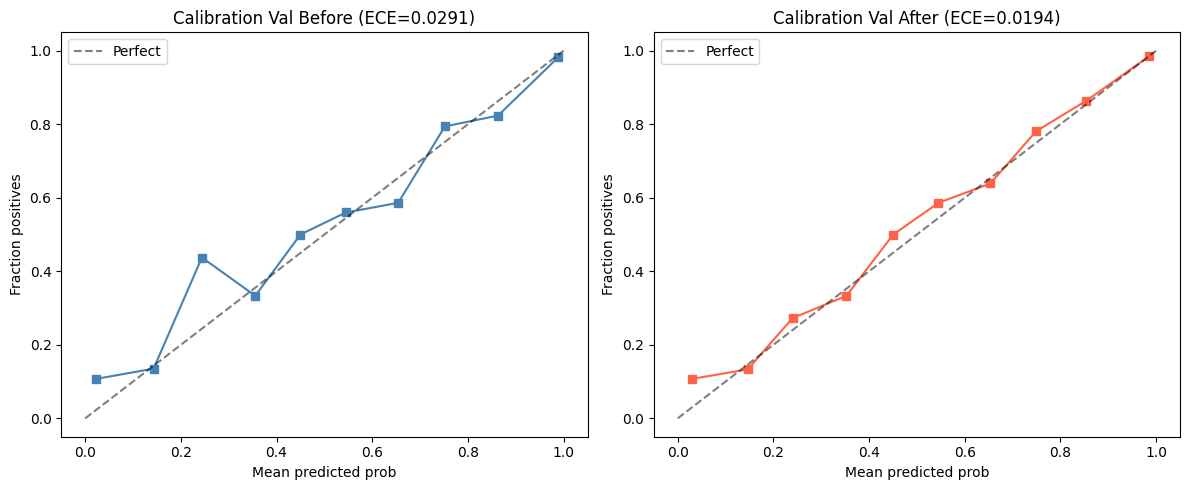

In [ ]:
# STEP 4 — Calibration (Temperature Scaling)
# ─────────────────────────────────────────────────────────────────────────────
# D1: T is fitted on val set for the final model.
# D2: ECE reported on both val (fitted) and test (out-of-sample) separately.
# N1 NOTE: Calibrated probabilities reflect the training distribution's pos/neg
#   ratio, NOT the true real-world warehouse prevalence. When scanning all
#   commercial properties in a new city, scores will be systematically
#   overestimated. Apply prior adjustment if real-world base rate is known.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 4 — Calibration (Temperature Scaling, fitted on val)")
print("="*60)

BEST_T = fit_temperature(FINAL_VAL_PROBS, FINAL_VAL_TRUE)

FINAL_VAL_PROBS_CAL  = temp_scale(np.array(FINAL_VAL_PROBS),  BEST_T)
FINAL_TEST_PROBS_CAL = temp_scale(np.array(FINAL_TEST_PROBS), BEST_T)

ece_val_before  = compute_ece(np.array(FINAL_VAL_PROBS),  FINAL_VAL_TRUE)
ece_val_after   = compute_ece(FINAL_VAL_PROBS_CAL,        FINAL_VAL_TRUE)
ece_test_before = compute_ece(np.array(FINAL_TEST_PROBS), FINAL_TEST_TRUE)
ece_test_after  = compute_ece(FINAL_TEST_PROBS_CAL,       FINAL_TEST_TRUE)

print(f"  T = {BEST_T:.4f}")
print(f"  Val  ECE (fitted):      {ece_val_before} -> {ece_val_after}")
print(f"  Test ECE (out-of-sample): {ece_test_before} -> {ece_test_after}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs_plot, true_plot, label, color in [
    (axes[0], np.array(FINAL_VAL_PROBS), FINAL_VAL_TRUE, "Val Before", "steelblue"),
    (axes[1], FINAL_VAL_PROBS_CAL,       FINAL_VAL_TRUE, "Val After",  "tomato"),
]:
    fp, mp = calibration_curve(true_plot, probs_plot, n_bins=10)
    ax.plot(mp, fp, "s-", color=color)
    ax.plot([0,1], [0,1], "k--", alpha=0.5, label="Perfect")
    ece = compute_ece(probs_plot, true_plot)
    ax.set_title(f"Calibration {label} (ECE={ece:.4f})")
    ax.set_xlabel("Mean predicted prob"); ax.set_ylabel("Fraction positives")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_curves_val.png"), dpi=150)
plt.show()

FINAL_PROBS_USE = FINAL_VAL_PROBS_CAL   # used in STEP 5 for threshold tuning (val)


STEP 5 — Threshold Tuning (val set)

  Val PR-AUC: 0.9860

  Name             T  Recall    Prec      F1  Use case
  ------------------------------------------------------------------------
  Sensitive    0.431  0.9501  0.9280  0.9389  Initial scan — maximise warehouse coverage
  Balanced     0.548  0.9322  0.9503  0.9412  Day-to-day operations
  Precise      0.206  0.9679  0.9004  0.9330  High-quality leads for human review


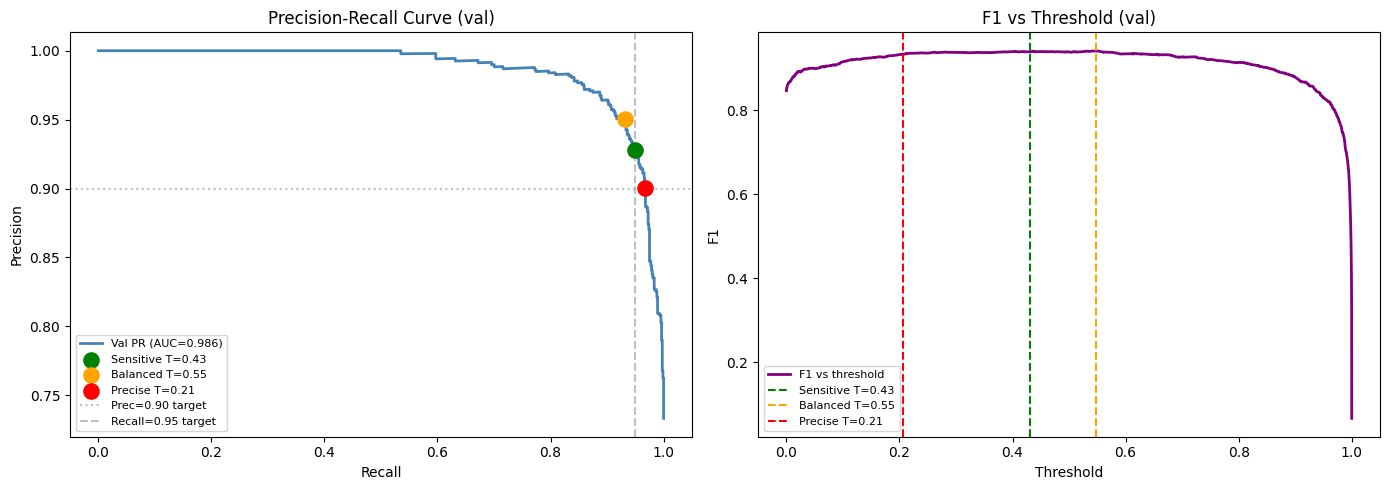


  Thresholds derived from val set. STEP 6 applies them to test set once.


In [ ]:
# STEP 5 — Threshold Tuning (val set)
# ─────────────────────────────────────────────────────────────────────────────
# C1 FIX: PR curve and threshold selection on val set (FINAL_PROBS_USE = val).
# M3 FIX: Threshold naming corrected to match business intuition:
#   "Sensitive" = low threshold, high recall  (initial screening, don't miss warehouses)
#   "Balanced"  = max F1 threshold            (day-to-day operations)
#   "Precise"   = high threshold, high prec   (high-quality leads for human review)
# N2 NOTE: recall >= 0.95 and precision >= 0.90 are working assumptions.
#   Replace with actual FP/FN cost ratio from business stakeholders.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 5 — Threshold Tuning (val set)")
print("="*60)

val_true_arr = np.array(FINAL_VAL_TRUE)
val_prob_arr = FINAL_PROBS_USE  # calibrated val probs

precision_curve, recall_curve, thresholds = precision_recall_curve(val_true_arr, val_prob_arr)
pr_auc   = auc(recall_curve, precision_curve)
f1_curve = 2*precision_curve*recall_curve / (precision_curve + recall_curve + 1e-8)

valid_sensitive = [(t,p,r) for t,p,r in
                   zip(thresholds, precision_curve[:-1], recall_curve[:-1]) if r >= 0.95]
valid_precise   = [(t,p,r) for t,p,r in
                   zip(thresholds, precision_curve[:-1], recall_curve[:-1]) if p >= 0.90]

T_SENSITIVE = max(valid_sensitive, key=lambda x: x[1])[0] if valid_sensitive else \
              float(thresholds[np.argmax(recall_curve[:-1])])
T_BALANCED  = float(thresholds[f1_curve[:-1].argmax()])
T_PRECISE   = min(valid_precise, key=lambda x: x[0])[0] if valid_precise else \
              float(thresholds[np.argmax(precision_curve[:-1] >= 0.90)])

m_sen = compute_metrics(FINAL_VAL_TRUE, val_prob_arr, T_SENSITIVE)
m_bal = compute_metrics(FINAL_VAL_TRUE, val_prob_arr, T_BALANCED)
m_pre = compute_metrics(FINAL_VAL_TRUE, val_prob_arr, T_PRECISE)

print(f"\n  Val PR-AUC: {pr_auc:.4f}")
print(f"\n  {'Name':<12} {'T':>5}  {'Recall':>6}  {'Prec':>6}  {'F1':>6}  Use case")
print("  " + "-"*72)
for name_, T, m, use in [
    ("Sensitive",  T_SENSITIVE, m_sen, "Initial scan — maximise warehouse coverage"),
    ("Balanced",   T_BALANCED,  m_bal, "Day-to-day operations"),
    ("Precise",    T_PRECISE,   m_pre, "High-quality leads for human review"),
]:
    print(f"  {name_:<12} {T:>5.3f}  {m['warehouse_recall']:>6.4f}  "
          f"{m['warehouse_precision']:>6.4f}  {m['warehouse_f1']:>6.4f}  {use}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recall_curve, precision_curve, color="steelblue", lw=2,
             label=f"Val PR (AUC={pr_auc:.3f})")
for name_, T, color in [("Sensitive",T_SENSITIVE,"green"),("Balanced",T_BALANCED,"orange"),
                          ("Precise",T_PRECISE,"red")]:
    m = compute_metrics(FINAL_VAL_TRUE, val_prob_arr, T)
    axes[0].scatter(m["warehouse_recall"], m["warehouse_precision"],
                    color=color, s=120, zorder=5, label=f"{name_} T={T:.2f}")
axes[0].axhline(0.9, color="gray", linestyle=":", alpha=0.5, label="Prec=0.90 target")
axes[0].axvline(0.95, color="gray", linestyle="--", alpha=0.5, label="Recall=0.95 target")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (val)"); axes[0].legend(fontsize=8)
axes[1].plot(thresholds, f1_curve[:-1], color="purple", lw=2, label="F1 vs threshold")
for name_, T, color in [("Sensitive",T_SENSITIVE,"green"),("Balanced",T_BALANCED,"orange"),
                          ("Precise",T_PRECISE,"red")]:
    axes[1].axvline(T, color=color, linestyle="--", label=f"{name_} T={T:.2f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs Threshold (val)"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_tuning_val.png"), dpi=150)
plt.show()

pd.DataFrame({
    "sensitive": {k:v for k,v in m_sen.items() if k != "preds"},
    "balanced":  {k:v for k,v in m_bal.items() if k != "preds"},
    "precise":   {k:v for k,v in m_pre.items() if k != "preds"},
}).T.to_csv(os.path.join(OUTPUT_DIR, "threshold_config.csv"))
print("\n  Thresholds derived from val set. STEP 6 applies them to test set once.")


STEP 6 — Final evaluation (test set)
                            model         threshold_type  warehouse_recall  warehouse_precision  macro_f1  test_pr_auc      recall_ci
             YOLO Run1 density_v2 balanced (val-derived)            0.9157               0.9437    0.8726       0.9770 0.9156+-0.0098
             YOLO Run2 density_v2 balanced (val-derived)            0.9002               0.9499    0.8674       0.9768 0.9000+-0.0103
          YOLO Run2+LS density_v2 balanced (val-derived)            0.9002               0.9499    0.8674       0.9768 0.9000+-0.0103
        YOLO Run1 baseline_global balanced (val-derived)            0.9347               0.9425    0.8858       0.9814 0.9345+-0.0084
        YOLO Run2 baseline_global balanced (val-derived)            0.9489               0.9422    0.8966       0.9802 0.9486+-0.0073
     YOLO Run2+LS baseline_global balanced (val-derived)            0.9489               0.9422    0.8966       0.9802 0.9486+-0.0073
                ResNet d

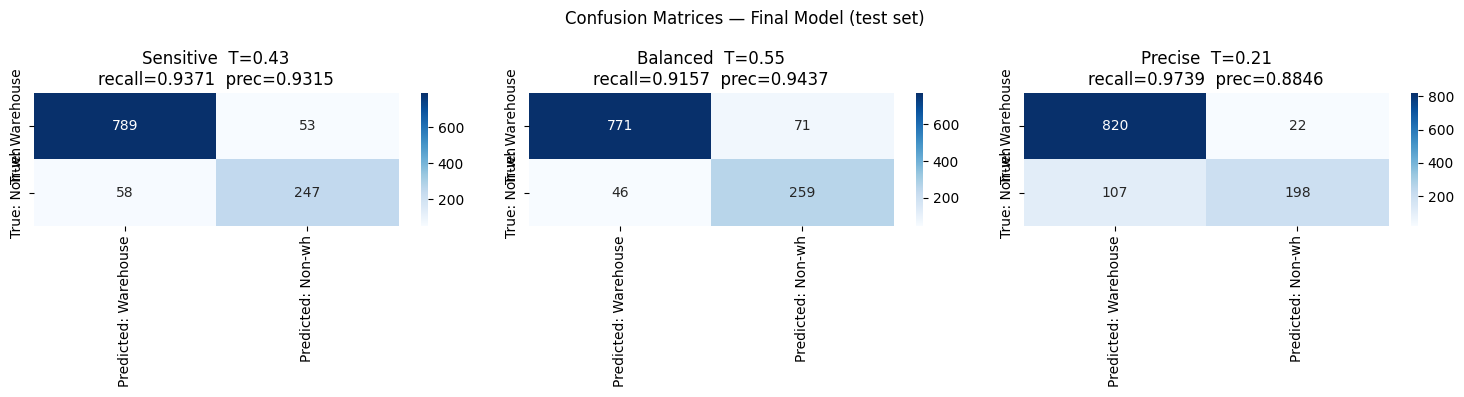

In [ ]:
# STEP 6 — Final evaluation (test set, one-time report)
# ─────────────────────────────────────────────────────────────────────────────
# All thresholds and calibration T come from val set (STEP 4 & 5).
# This is the first and only use of test set for reporting.
# E2 FIX: Restore CI in final report.
# M8 FIX: Confusion matrix axes labeled clearly (Predicted / True).
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 6 — Final evaluation (test set)")
print("="*60)

test_prob_arr = FINAL_TEST_PROBS_CAL  # calibrated with val-fitted T
m_sen_test = compute_metrics(FINAL_TEST_TRUE, test_prob_arr, T_SENSITIVE)
m_bal_test = compute_metrics(FINAL_TEST_TRUE, test_prob_arr, T_BALANCED)
m_pre_test = compute_metrics(FINAL_TEST_TRUE, test_prob_arr, T_PRECISE)

final_rows = []
# All non-spatial models at balanced threshold (each with its own val-fitted T)
for model_key, res in all_results.items():
    if "Spatial" in model_key:
        continue
    probs_cal = temp_scale(np.array(res["test_probs"]), res["val_T"])
    m  = compute_metrics(res["test_true"], probs_cal, T_BALANCED)
    ci = bootstrap_ci(res["test_true"], probs_cal, threshold=T_BALANCED)
    final_rows.append({
        "model":               model_key,
        "threshold_type":      "balanced (val-derived)",
        "warehouse_recall":    m["warehouse_recall"],
        "warehouse_precision": m["warehouse_precision"],
        "warehouse_f1":        m["warehouse_f1"],
        "non_wh_f1":           m["non_wh_f1"],
        "macro_f1":            m["macro_f1"],
        "test_pr_auc":         res["test_pr_auc"],
        "recall_ci":    f"{ci['recall']['mean']:.4f}+-{ci['recall']['std']:.4f}",
        "precision_ci": f"{ci['precision']['mean']:.4f}+-{ci['precision']['std']:.4f}",
        "macro_f1_ci":  f"{ci['macro_f1']['mean']:.4f}+-{ci['macro_f1']['std']:.4f}",
        "fine_tuned":   False,
    })

# Fine-tuned model at all 3 thresholds
for tname, T, m in [("sensitive",T_SENSITIVE,m_sen_test),
                     ("balanced", T_BALANCED, m_bal_test),
                     ("precise",  T_PRECISE,  m_pre_test)]:
    ci = bootstrap_ci(FINAL_TEST_TRUE, test_prob_arr, threshold=T)
    final_rows.append({
        "model":               f"Fine-tuned ({BEST_MODEL_KEY})",
        "threshold_type":      tname,
        "warehouse_recall":    m["warehouse_recall"],
        "warehouse_precision": m["warehouse_precision"],
        "warehouse_f1":        m["warehouse_f1"],
        "non_wh_f1":           m["non_wh_f1"],
        "macro_f1":            m["macro_f1"],
        "test_pr_auc":         compute_pr_auc(FINAL_TEST_TRUE, test_prob_arr),
        "recall_ci":    f"{ci['recall']['mean']:.4f}+-{ci['recall']['std']:.4f}",
        "precision_ci": f"{ci['precision']['mean']:.4f}+-{ci['precision']['std']:.4f}",
        "macro_f1_ci":  f"{ci['macro_f1']['mean']:.4f}+-{ci['macro_f1']['std']:.4f}",
        "fine_tuned":   True,
    })

final_df = pd.DataFrame(final_rows)
print(final_df[["model","threshold_type","warehouse_recall","warehouse_precision",
                "macro_f1","test_pr_auc","recall_ci"]].to_string(index=False))
final_df.to_csv(os.path.join(OUTPUT_DIR, "final_evaluation.csv"), index=False)

# M8 FIX: Confusion matrices with clear axis labels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tname, T, m) in zip(axes, [
    ("Sensitive", T_SENSITIVE, m_sen_test),
    ("Balanced",  T_BALANCED,  m_bal_test),
    ("Precise",   T_PRECISE,   m_pre_test),
]):
    cm = confusion_matrix(FINAL_TEST_TRUE, m["preds"], labels=[1, 0])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted: Warehouse", "Predicted: Non-wh"],
                yticklabels=["True: Warehouse",      "True: Non-wh"], ax=ax)
    ax.set_title(f"{tname}  T={T:.2f}\n"
                 f"recall={m['warehouse_recall']}  prec={m['warehouse_precision']}")
plt.suptitle("Confusion Matrices — Final Model (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices_final.png"), dpi=150)
plt.show()


STEP 7 — Training curves


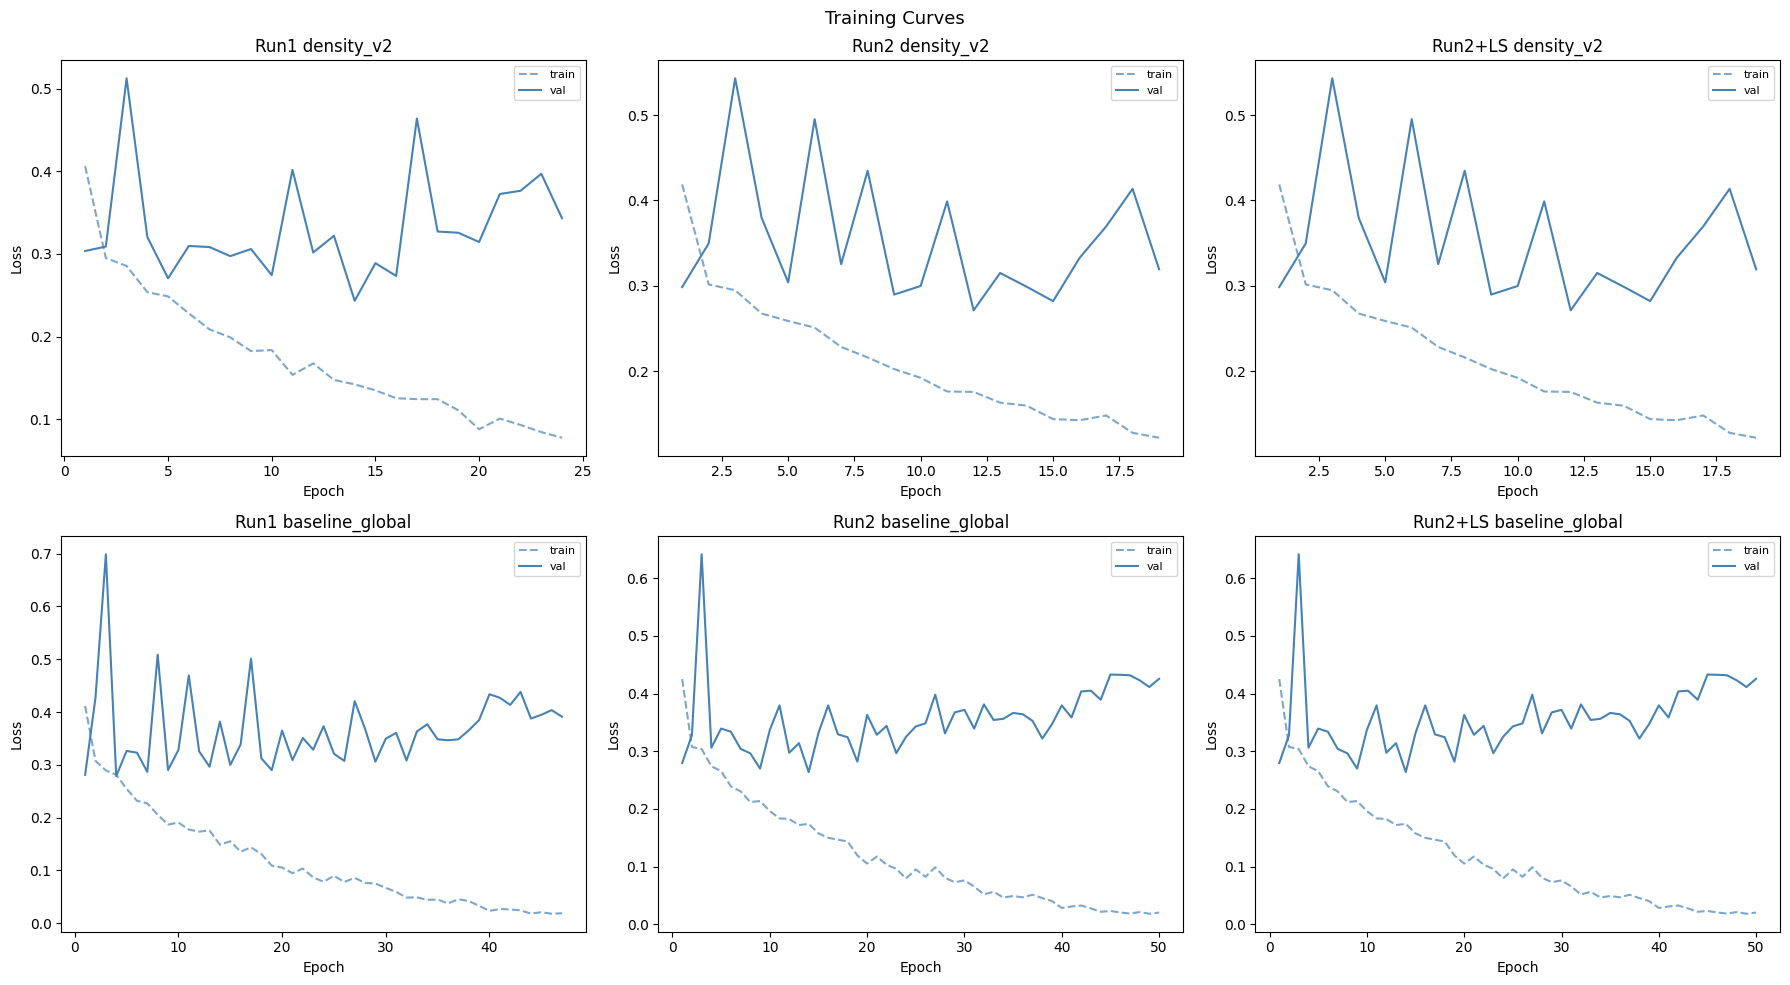

In [ ]:
# STEP 7 — Training curves
print("\n" + "="*60)
print("STEP 7 — Training curves")
print("="*60)

CURVE_RUNS = {
    "Run1 density_v2":         STRATEGIES["density_v2"]["run1_name"],
    "Run2 density_v2":         STRATEGIES["density_v2"]["run2_name"],
    "Run2+LS density_v2":      STRATEGIES["density_v2"]["run2ls_name"],
    "Run1 baseline_global":    STRATEGIES["baseline_global"]["run1_name"],
    "Run2 baseline_global":    STRATEGIES["baseline_global"]["run2_name"],
    "Run2+LS baseline_global": STRATEGIES["baseline_global"]["run2ls_name"],
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (label, run_name) in zip(axes.flatten(), CURVE_RUNS.items()):
    csv_path = os.path.join(RUNS_DIR, run_name, "results.csv")
    if not os.path.exists(csv_path):
        ax.set_title(f"{label}\n(no data)"); ax.axis("off"); continue
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    ax.plot(df["epoch"], df["train/loss"], "--", color="steelblue", alpha=0.7, label="train")
    ax.plot(df["epoch"], df["val/loss"],   "-",  color="steelblue", label="val")
    ax.set_title(label); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8)
plt.suptitle("Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()


STEP 8 — Error analysis by OSM category

-- FP Rate by OSM Category (balanced T=0.55) --
  High FP in wholesale/factory/industrial indicates the model captures
  warehouse-like logistics morphology. These may be secondary review candidates.

  Category                  N   FP   Rate  95% CI
  ----------------------------------------------------
  wholesale                36   24  0.667  [0.503, 0.798]
  sports_centre            25    6  0.240  [0.115, 0.434]
  industrial               20    3  0.150  [0.052, 0.36]
  hospital                 21    3  0.143  [0.05, 0.346]
  restaurant               20    2  0.100  [0.028, 0.301]
  supermarket              21    2  0.095  [0.027, 0.289]
  hotel                    21    2  0.095  [0.027, 0.289]
  commercial               18    1  0.056  [0.01, 0.258]
  park                     19    1  0.053  [0.009, 0.246]
  school                   22    1  0.045  [0.008, 0.218]
  retail_large             27    1  0.037  [0.007, 0.183]
  factory        

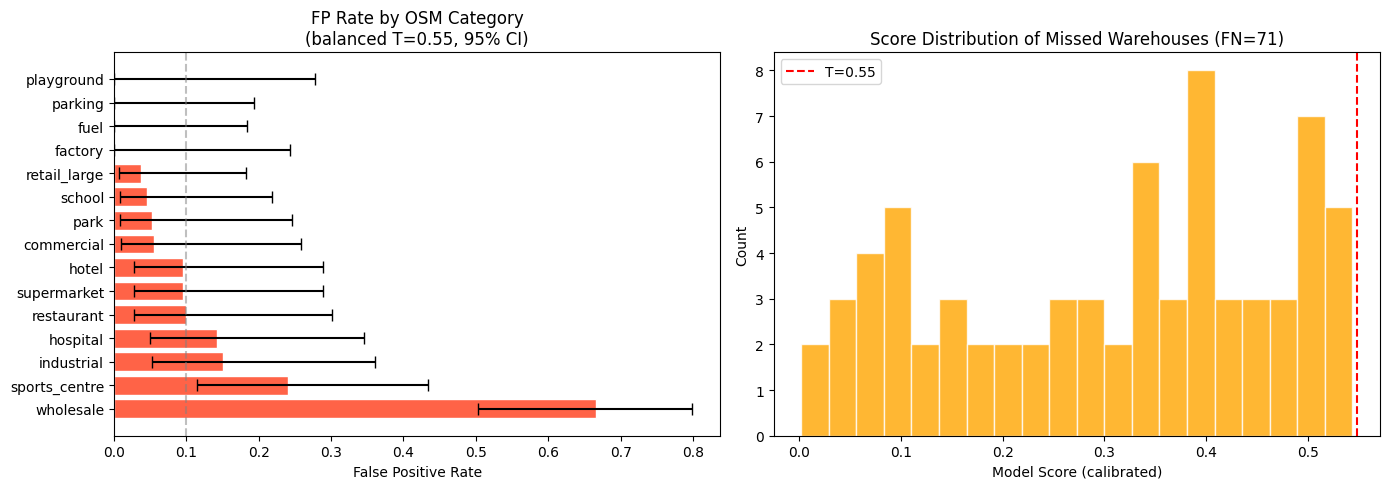

In [ ]:
# STEP 8 — Error analysis by OSM category
# ─────────────────────────────────────────────────────────────────────────────
# E3 FIX: Added FN (missed warehouse) analysis alongside FP analysis.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 8 — Error analysis by OSM category")
print("="*60)

error_df = pd.DataFrame({
    "true":     FINAL_TEST_TRUE,
    "pred":     m_bal_test["preds"],
    "prob":     test_prob_arr.tolist(),
    "category": FINAL_TEST_CATS,
    "path":     FINAL_TEST_PATHS,
})

# ── FP analysis ──────────────────────────────────────────────────────────────
neg_df = error_df[(error_df["true"] == 0) & error_df["category"].notna()].copy()
neg_df["fp"] = (neg_df["pred"] == 1).astype(int)

cat_stats = (
    neg_df.groupby("category")
    .agg(total=("fp","count"), fp_count=("fp","sum"))
    .assign(fp_rate=lambda x: x["fp_count"]/x["total"])
    .sort_values("fp_rate", ascending=False)
)
cat_stats["ci_lower"], cat_stats["ci_upper"] = zip(*[
    wilson_ci(int(r["fp_count"]), int(r["total"]))
    for _, r in cat_stats.iterrows()
])

print(f"\n-- FP Rate by OSM Category (balanced T={T_BALANCED:.2f}) --")
print(f"  High FP in wholesale/factory/industrial indicates the model captures")
print(f"  warehouse-like logistics morphology. These may be secondary review candidates.")
print(f"\n  {'Category':<22} {'N':>4} {'FP':>4} {'Rate':>6}  95% CI")
print("  " + "-"*52)
for cat, row in cat_stats.iterrows():
    print(f"  {cat:<22} {int(row['total']):>4} {int(row['fp_count']):>4} "
          f"{row['fp_rate']:>6.3f}  [{row['ci_lower']}, {row['ci_upper']}]")

# ── FN analysis ──────────────────────────────────────────────────────────────
fn_df = error_df[(error_df["true"] == 1) & (error_df["pred"] == 0)].copy()
n_wh  = error_df["true"].sum()

print(f"\n-- Missed Warehouses (FN) at balanced T={T_BALANCED:.2f} --")
print(f"  Total FN: {len(fn_df)}  ({100*len(fn_df)/max(n_wh,1):.1f}% of all warehouses)")
if len(fn_df) > 0:
    print(f"  Mean score of FN: {fn_df['prob'].mean():.4f}")
    print(fn_df["prob"].describe().round(4).to_string())
    near = ((fn_df["prob"] >= T_BALANCED - 0.1) & (fn_df["prob"] < T_BALANCED)).sum()
    far  = (fn_df["prob"] < T_BALANCED - 0.2).sum()
    print(f"\n  Within 0.10 of threshold (borderline misses): {near} ({100*near/len(fn_df):.1f}%)")
    print(f"  More than 0.20 below threshold (confident misses): {far} ({100*far/len(fn_df):.1f}%)")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cats   = cat_stats.index.tolist()
rates  = cat_stats["fp_rate"].values
ci_low = rates - cat_stats["ci_lower"].values
ci_hi  = cat_stats["ci_upper"].values - rates
axes[0].barh(cats, rates, xerr=np.array([ci_low, ci_hi]),
             color="tomato", edgecolor="white", capsize=4)
axes[0].axvline(0.1, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title(f"FP Rate by OSM Category\n(balanced T={T_BALANCED:.2f}, 95% CI)")
axes[0].set_xlabel("False Positive Rate")

if len(fn_df) > 0:
    axes[1].hist(fn_df["prob"], bins=20, color="orange", edgecolor="white", alpha=0.8)
    axes[1].axvline(T_BALANCED, color="red", linestyle="--", label=f"T={T_BALANCED:.2f}")
    axes[1].set_xlabel("Model Score (calibrated)"); axes[1].set_ylabel("Count")
    axes[1].set_title(f"Score Distribution of Missed Warehouses (FN={len(fn_df)})")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No FN at this threshold", ha="center", va="center",
                 transform=axes[1].transAxes)
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "error_analysis.png"), dpi=150)
plt.show()

cat_stats.to_csv(os.path.join(OUTPUT_DIR, "fp_by_category_final.csv"))
if len(fn_df) > 0:
    fn_df[["prob","path"]].to_csv(os.path.join(OUTPUT_DIR, "fn_analysis.csv"), index=False)


STEP 9 — Tiered classification

  Tier                                 N  Precision            95% CI  Note
  ----------------------------------------------------------------------------------
  Core Warehouse Candidate           817      0.944  [0.926, 0.958]
  Secondary Logistics Candidate      110      0.445  [0.356, 0.539]
  Deprioritized                      220      0.100  [0.067, 0.147]  <- includes 22 warehouse(s)

  'Deprioritized' does not mean confirmed non-warehouse.
  Use Sensitive threshold (T=0.43) for full coverage scans.


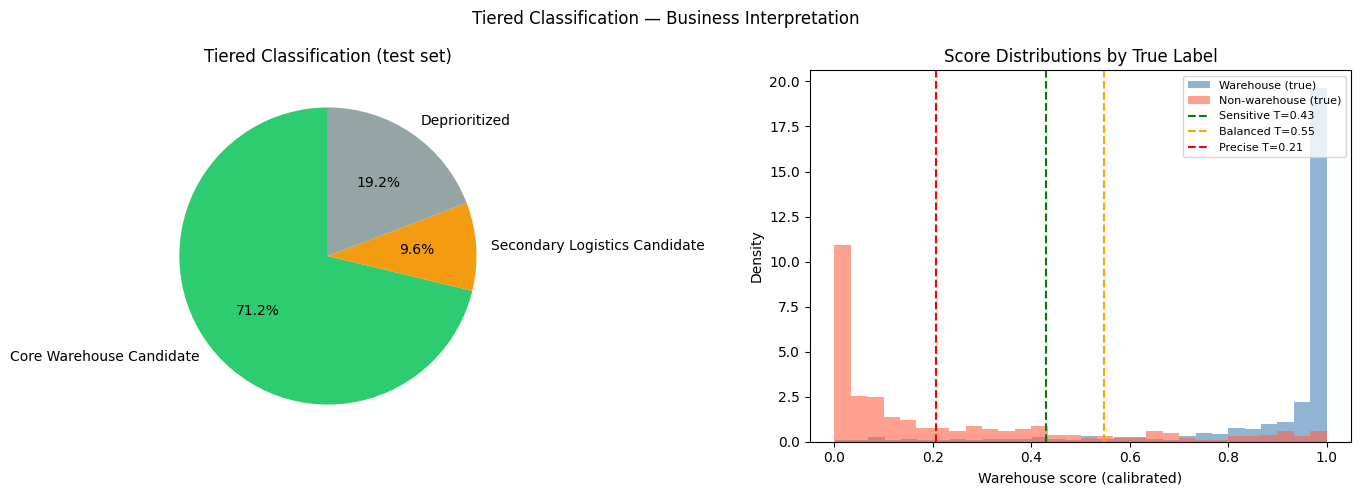

In [ ]:
# STEP 9 — Tiered classification
# ─────────────────────────────────────────────────────────────────────────────
# M4 FIX: Tier precision reported with Wilson CI.
# Tier naming updated:
#   "Core Warehouse Candidate"       (>= T_PRECISE)
#   "Secondary Logistics Candidate"  (>= T_SENSITIVE and < T_PRECISE)
#   "Deprioritized"                  (< T_SENSITIVE)
# "Deprioritized" replaces "Not a Target" — lower-priority points may still
# contain undetected warehouses (FN), so do not treat as confirmed negatives.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 9 — Tiered classification")
print("="*60)

T_LOW  = min(T_SENSITIVE, T_BALANCED, T_PRECISE)
T_HIGH = max(T_SENSITIVE, T_BALANCED, T_PRECISE)


def classify_tiered(prob):
    if prob >= T_HIGH:  return "Core Warehouse Candidate"
    elif prob >= T_LOW: return "Secondary Logistics Candidate"
    else:               return "Deprioritized"


tiers = [classify_tiered(p) for p in test_prob_arr]
tier_order = ["Core Warehouse Candidate", "Secondary Logistics Candidate", "Deprioritized"]
tier_colors_map = {
    "Core Warehouse Candidate":      "#2ecc71",
    "Secondary Logistics Candidate": "#f39c12",
    "Deprioritized":                 "#95a5a6",
}

print(f"\n  {'Tier':<32} {'N':>5}  {'Precision':>9}  {'95% CI':>16}  Note")
print("  " + "-"*82)
for tier in tier_order:
    mask  = np.array(tiers) == tier
    count = mask.sum()
    tp    = int(np.array(FINAL_TEST_TRUE)[mask].sum())
    prec  = tp / count if count > 0 else 0.0
    lo, hi = wilson_ci(tp, count)
    note = ""
    if tier == "Deprioritized":
        fn_in_tier = int(np.array(FINAL_TEST_TRUE)[mask].sum())
        note = f"  <- includes {fn_in_tier} warehouse(s)"
    print(f"  {tier:<32} {count:>5}  {prec:>9.3f}  [{lo:.3f}, {hi:.3f}]{note}")

print(f"\n  'Deprioritized' does not mean confirmed non-warehouse.")
print(f"  Use Sensitive threshold (T={T_SENSITIVE:.2f}) for full coverage scans.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts_ord = [pd.Series(tiers).value_counts().get(t, 0) for t in tier_order]
axes[0].pie(counts_ord, labels=tier_order,
            colors=[tier_colors_map[t] for t in tier_order],
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Tiered Classification (test set)")

wh_probs  = [p for p,l in zip(test_prob_arr, FINAL_TEST_TRUE) if l == 1]
nwh_probs = [p for p,l in zip(test_prob_arr, FINAL_TEST_TRUE) if l == 0]
axes[1].hist(wh_probs,  bins=30, alpha=0.6, color="steelblue",
             label="Warehouse (true)", density=True)
axes[1].hist(nwh_probs, bins=30, alpha=0.6, color="tomato",
             label="Non-warehouse (true)", density=True)
for name_, T, color in [("Sensitive",T_SENSITIVE,"green"),("Balanced",T_BALANCED,"orange"),
                          ("Precise",T_PRECISE,"red")]:
    axes[1].axvline(T, color=color, linestyle="--", label=f"{name_} T={T:.2f}")
axes[1].set_xlabel("Warehouse score (calibrated)"); axes[1].set_ylabel("Density")
axes[1].set_title("Score Distributions by True Label"); axes[1].legend(fontsize=8)
plt.suptitle("Tiered Classification — Business Interpretation", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tiered_classification.png"), dpi=150)
plt.show()

In [ ]:
# STEP 10 — Representative images
df_rep = pd.DataFrame({
    "path": FINAL_TEST_PATHS, "true": FINAL_TEST_TRUE,
    "pred": m_bal_test["preds"], "prob": test_prob_arr.tolist(),
})
tp = df_rep[(df_rep["true"]==1) & (df_rep["pred"]==1)]
tn = df_rep[(df_rep["true"]==0) & (df_rep["pred"]==0)]
fp = df_rep[(df_rep["true"]==0) & (df_rep["pred"]==1)]
fn = df_rep[(df_rep["true"]==1) & (df_rep["pred"]==0)]

rep_images = {
    "TP": tp.nlargest(2,"prob")["path"].tolist(),
    "TN": tn.nsmallest(2,"prob")["path"].tolist(),
    "FP": fp.nlargest(2,"prob")["path"].tolist(),
    "FN": fn.nsmallest(2,"prob")["path"].tolist(),
}
type_colors = {"TP":"green","TN":"blue","FP":"red","FN":"orange"}
type_desc   = {
    "TP": "Warehouse correctly identified",
    "TN": "Non-warehouse correctly rejected",
    "FP": "Non-wh misclassified as warehouse\n(may indicate warehouse-like morphology)",
    "FN": "Warehouse missed by model",
}
for k, v in rep_images.items():
    print(f"  {k}: {len(v)} images")

  TP: 2 images
  TN: 2 images
  FP: 2 images
  FN: 2 images


In [ ]:
# STEP 11 — GradCAM
# ─────────────────────────────────────────────────────────────────────────────
# G1 FIX: Use save=True with explicit absolute output path.
#         Handle missing cam files gracefully with fallback message.
# G2 FIX: Use RUNS_DIR absolute path instead of relative "runs/classify/predict".
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 11 — GradCAM")
print("="*60)

yolo_best = YOLO(FINAL_WEIGHTS)
CAM_DIR   = Path(RUNS_DIR) / "gradcam_tmp"
CAM_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(4, 3, figsize=(13, 17))

for row_idx, img_type in enumerate(["TP","TN","FP","FN"]):
    color    = type_colors[img_type]
    img_list = rep_images[img_type]

    for col_idx in range(2):
        ax = axes[row_idx][col_idx]
        if col_idx < len(img_list):
            ax.imshow(Image.open(img_list[col_idx]).convert("RGB"))
            ax.set_title(f"{img_type} ({col_idx+1})", color=color, fontsize=9)
            for sp in ax.spines.values():
                sp.set_edgecolor(color); sp.set_linewidth(2)
        ax.axis("off")

    ax_cam = axes[row_idx][2]
    ax_cam.axis("off")
    if img_list:
        # G1 + G2 FIX: save=True with absolute output dir; find file after saving
        cam_run_name = f"cam_{img_type}"
        cam_run_dir  = CAM_DIR / cam_run_name
        try:
            yolo_best.predict(
                img_list[0], visualize=True, save=True,
                project=str(CAM_DIR), name=cam_run_name,
                exist_ok=True, verbose=False,
            )
            cam_files = sorted(
                cam_run_dir.glob("**/*.png"),
                key=lambda p: p.stat().st_mtime,
            )
            if cam_files:
                ax_cam.imshow(Image.open(cam_files[-1]).convert("RGB"))
                ax_cam.set_title(f"{img_type} GradCAM\n{type_desc[img_type]}",
                                 fontsize=8, color=color)
            else:
                ax_cam.set_title(f"{img_type} GradCAM\n(not available — check ultralytics version)",
                                 fontsize=8)
        except Exception as e:
            ax_cam.set_title(f"{img_type} GradCAM\n(error: {e})", fontsize=7)

plt.suptitle("GradCAM — Final Model (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_final.png"), dpi=150, bbox_inches="tight")
plt.show()


STEP 11 — GradCAM
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage0_Conv_features.png... (32/32)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage1_Conv_features.png... (32/64)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage2_C2f_features.png... (32/64)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage3_Conv_features.png... (32/128)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage4_C2f_features.png... (32/128)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage5_Conv_features.png... (32/256)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage6_C2f_features.png... (32/256)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage7_Conv_features.png... (32/512)
Saving /content/runs/classify/gradcam_tmp/cam_TP/pos_510/stage8_C2f_features.png... (32/512)
Results saved to /content/runs/classify/gradcam_tmp/cam_TP
Saving /content/runs/classify/gradcam_tmp/cam_TN/neg_1007/stage0_Conv_features.png.

<Figure size 640x480 with 0 Axes>


STEP 12 — SHAP
  Running SHAP on 8 images (uint8 input)...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  12%|█▎        | 1/8 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  38%|███▊      | 3/8 [00:21<00:22,  4.47s/it]

...

PartitionExplainer explainer:  88%|████████▊ | 7/8 [00:56<00:08,  8.10s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 8/8 [01:05<00:00,  8.11s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 9it [01:13,  9.22s/it]


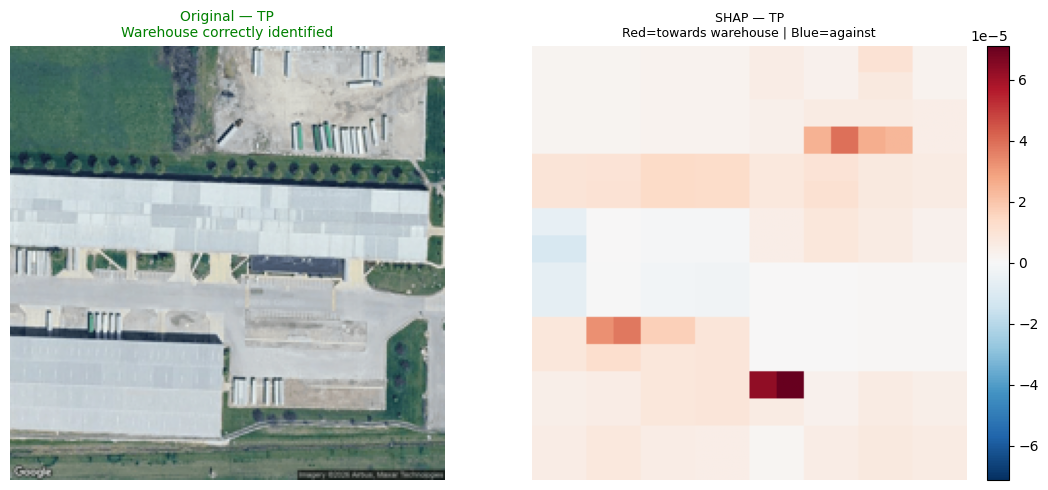

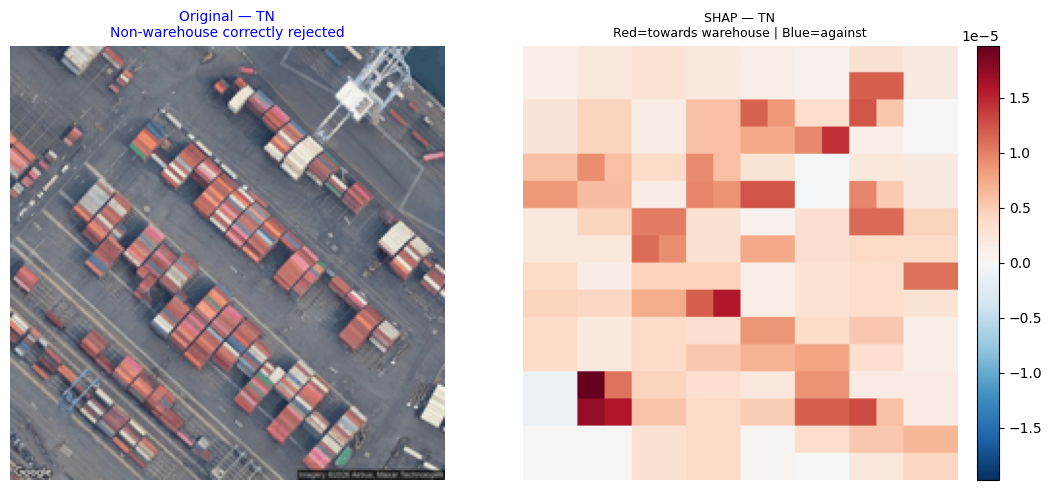

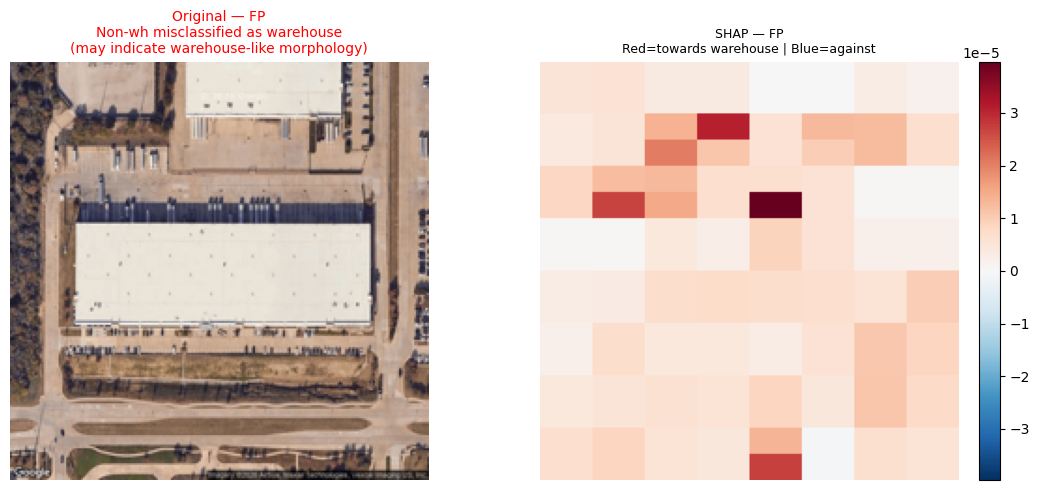

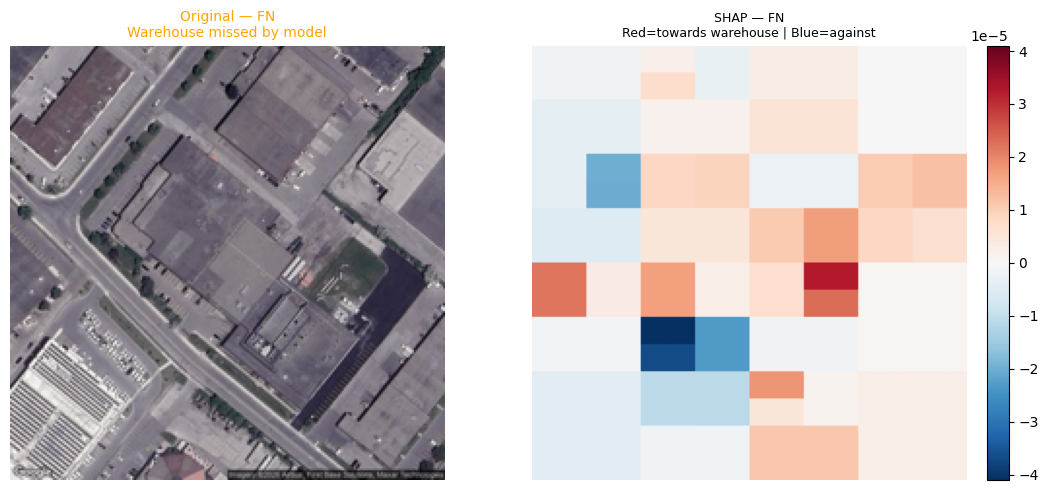

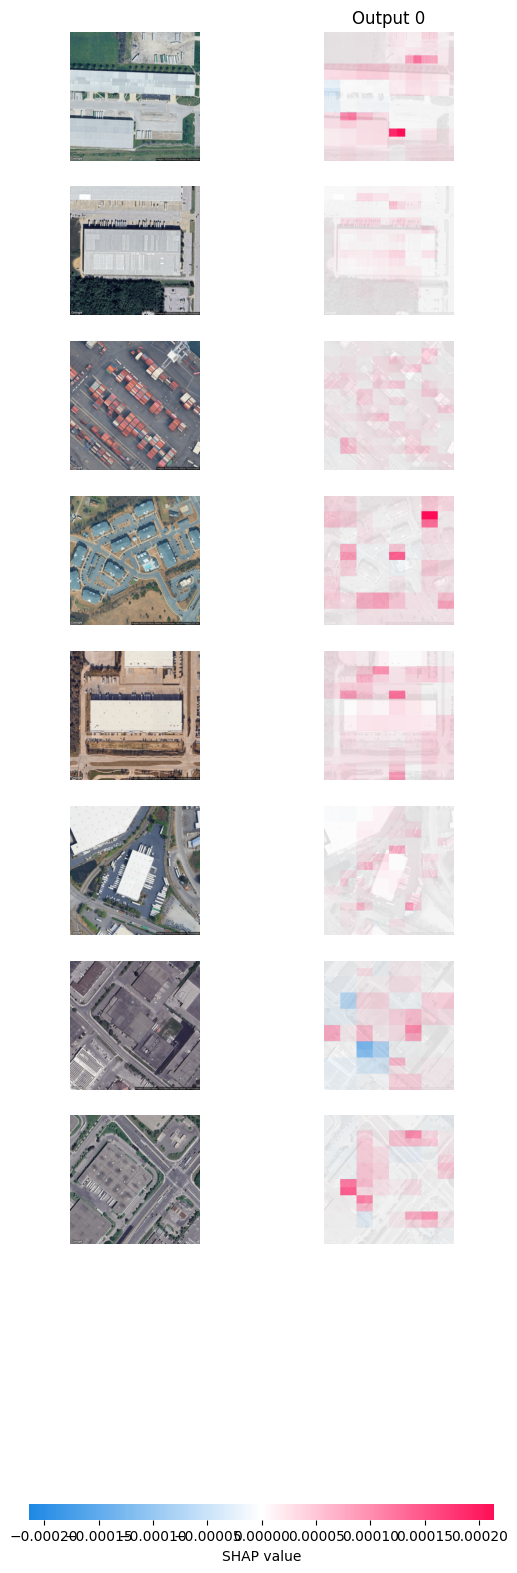

<Figure size 640x480 with 0 Axes>

In [ ]:
# STEP 12 — SHAP
# ─────────────────────────────────────────────────────────────────────────────
# H1 FIX: SHAP masker and prediction function now both operate on uint8 [0,255].
# Original bug: masker perturbed float [0,1] images while predict() converted
# them back to uint8 — the perturbation happened in a different space than
# the model's actual input, making attributions unreliable.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 12 — SHAP")
print("="*60)

shap_model = YOLO(FINAL_WEIGHTS)

shap_paths, shap_types = [], []
for img_type in ["TP","TN","FP","FN"]:
    for p in rep_images[img_type]:
        shap_paths.append(p); shap_types.append(img_type)

# H1 FIX: Load as uint8 [0,255] — consistent with YOLO's expected input
shap_images_uint8 = np.array([
    np.array(Image.open(p).convert("RGB").resize((224, 224))).astype(np.uint8)
    for p in shap_paths
])


def yolo_predict_for_shap(images_nhwc):
    """images_nhwc is uint8 [0,255] — no conversion needed."""
    return np.array([
        shap_model(img, verbose=False)[0].probs.data.cpu().numpy()
        for img in images_nhwc
    ])


print(f"  Running SHAP on {len(shap_paths)} images (uint8 input)...")
masker      = shap.maskers.Image("blur(28,28)", shap_images_uint8[0].shape)
explainer   = shap.Explainer(yolo_predict_for_shap, masker)
shap_values = explainer(shap_images_uint8, max_evals=500, batch_size=8,
                        outputs=shap.Explanation.argsort.flip[:1])

for img_type in ["TP","TN","FP","FN"]:
    idx   = next(i for i,t in enumerate(shap_types) if t == img_type)
    color = type_colors[img_type]
    fig, ax2 = plt.subplots(1, 2, figsize=(11, 5))
    ax2[0].imshow(shap_images_uint8[idx])
    ax2[0].set_title(f"Original — {img_type}\n{type_desc[img_type]}", color=color, fontsize=10)
    ax2[0].axis("off")
    hmap = shap_values[idx].values[...,0].mean(axis=-1)
    im   = ax2[1].imshow(hmap, cmap="RdBu_r",
                          vmin=-np.abs(hmap).max(), vmax=np.abs(hmap).max())
    ax2[1].set_title(f"SHAP — {img_type}\nRed=towards warehouse | Blue=against", fontsize=9)
    ax2[1].axis("off")
    plt.colorbar(im, ax=ax2[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"shap_{img_type}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

shap.image_plot(shap_values, shap_images_uint8)
plt.savefig(os.path.join(OUTPUT_DIR, "shap_panel.png"), dpi=150, bbox_inches="tight")

In [ ]:
# STEP 13 — Save to Drive
print("\n" + "="*60)
print("STEP 13 — Save to Drive")
print("="*60)

os.makedirs("/drive/MyDrive/yolo_weights", exist_ok=True)
shutil.copy2(FINAL_WEIGHTS, "/drive/MyDrive/yolo_weights/finetune_hardneg_best.pt")

eval_drive = "/drive/MyDrive/evaluation"
if os.path.exists(eval_drive):
    shutil.rmtree(eval_drive)
shutil.copytree(OUTPUT_DIR, eval_drive)

print(f"  Weights -> /drive/MyDrive/yolo_weights/finetune_hardneg_best.pt")
print(f"  Outputs -> {eval_drive}")
print(f"\nFiles saved:")
for f in sorted(Path(OUTPUT_DIR).glob("*")):
    print(f"  {f.name}")
print("\n✅ Pipeline complete.")


STEP 13 — Save to Drive
  Weights -> /drive/MyDrive/yolo_weights/finetune_hardneg_best.pt
  Outputs -> /drive/MyDrive/evaluation

Files saved:
  calibration_curves_val.png
  confusion_matrices_final.png
  error_analysis.png
  final_evaluation.csv
  fn_analysis.csv
  fp_by_category_final.csv
  gradcam_final.png
  model_selection_summary.csv
  shap_FN.png
  shap_FP.png
  shap_TN.png
  shap_TP.png
  shap_panel.png
  threshold_config.csv
  threshold_tuning_val.png
  tiered_classification.png
  training_curves.png

✅ Pipeline complete.
